In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!cp -r '/content/drive/MyDrive/UNSW-NB15' '/content/'

In [3]:
import torch, sys
print(f'Python version: {sys.version.split()[0]}')
print(f'Pytorch version: {torch.version}')
print(f'Cuda Version : {torch.version.cuda}')

!pip install torch_geometric -q

# TORCH = torch.__version__.split("+")[0]          # e.g. "2.3.0"
# CUDA  = "cu" + torch.version.cuda.replace(".","")[:4]  # e.g. "cu121"
# !pip install torch_scatter torch_sparse \
#     -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html -q

!pip install pandas numpy scikit-learn matplotlib seaborn networkx tqdm -q

print('All packges are Installed !')

Python version: 3.12.13
Pytorch version: <module 'torch.version' from '/usr/local/lib/python3.12/dist-packages/torch/version.py'>
Cuda Version : None
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00
All packges are Installed !


In [4]:
import os, random, warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data   import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn     import MessagePassing

from sklearn.preprocessing  import StandardScaler, LabelEncoder
from sklearn.metrics        import (classification_report,
                                    confusion_matrix,
                                    roc_auc_score, f1_score)

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED);  np.random.seed(SEED);  torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


In [5]:
# ── Cell 3: Master config ────────────────────────────────────────────────────
CFG = {
    # ── data ──────────────────────────────────────────────────────────────────
    "data_dir"     : "/content/UNSW-NB15/",      # ← change to your CSV folder path

    # ── window sampling ────────────────────────────────────────────────────────
    "min_window"   : 100,     # minimum flows per window
    "max_window"   : 800,     # maximum flows per window
    "n_train"      : 200,     # random windows for training
    "n_val"        : 50,      # random windows for validation
    "n_test"       : 50,      # random windows for testing

    # ── graph construction ─────────────────────────────────────────────────────
    "max_ip_edges" : 8,       # max edges per shared-IP group
    "temporal_k"   : 5,       # k nearest temporal neighbours per flow
    "edge_dim"     : 7,       # edge feature size (fixed — don't change)

    # ── model ──────────────────────────────────────────────────────────────────
    "hidden_dim"   : 128,
    "num_layers"   : 3,
    "dropout"      : 0.3,

    # ── training ───────────────────────────────────────────────────────────────
    "batch_size"   : 16,      # graphs per batch
    "lr"           : 1e-3,
    "weight_decay" : 1e-5,
    "epochs"       : 100,
    "patience"     : 15,      # early stopping patience

}

CFG["stratify_train"] = True    # oversample attack-rich windows for training
CFG["stratify_eval"]  = False   # realistic distribution for val/test

print("Config loaded ✅")
for k, v in CFG.items():
    print(f"  {k:<16} = {v}")

Config loaded ✅
  data_dir         = /content/UNSW-NB15/
  min_window       = 100
  max_window       = 800
  n_train          = 200
  n_val            = 50
  n_test           = 50
  max_ip_edges     = 8
  temporal_k       = 5
  edge_dim         = 7
  hidden_dim       = 128
  num_layers       = 3
  dropout          = 0.3
  batch_size       = 16
  lr               = 0.001
  weight_decay     = 1e-05
  epochs           = 100
  patience         = 15
  stratify_train   = True
  stratify_eval    = False


In [6]:
# ── Cell 4: Column definitions & loader ────────────────────────────────────

COLUMNS = [
    "srcip","sport","dstip","dsport","proto","state","dur",
    "sbytes","dbytes","sttl","dttl","sloss","dloss","service",
    "sload","dload","spkts","dpkts","swin","dwin","stcpb","dtcpb",
    "sinpkt","dinpkt","sjit","djit","stime","ltime","tcprtt",
    "synack","ackdat","smean","dmean","trans_depth","response_body_len",
    "ct_srv_src","ct_state_ttl","ct_dst_ltm","ct_src_dport_ltm",
    "ct_dst_sport_ltm","ct_dst_src_ltm","is_ftp_login","ct_ftp_cmd",
    "ct_flw_http_mthd","ct_src_ltm","ct_srv_dst","is_sm_ips_ports",
    "attack_cat","label"
]

# Features used as NODE features (exclude IPs, ports, timestamps, label)
GRAPH_COLS = [
    "dur","sbytes","dbytes","sttl","dttl","sloss","dloss",
    "sload","dload","spkts","dpkts","swin","dwin","sinpkt","dinpkt",
    "sjit","djit","tcprtt","synack","ackdat","smean","dmean",
    "trans_depth","response_body_len","ct_srv_src","ct_state_ttl",
    "ct_dst_ltm","ct_src_dport_ltm","ct_dst_sport_ltm","ct_dst_src_ltm",
    "ct_src_ltm","ct_srv_dst","is_ftp_login","is_sm_ips_ports",
    # encoded categoricals added later:
    "proto_enc","state_enc","service_enc"
]

def load_unswnb15(data_dir: str) -> pd.DataFrame:
    """Load all UNSW-NB15 CSV files from a folder into one DataFrame."""
    data_dir = Path(data_dir)
    csv_files = sorted(data_dir.glob("UNSW-NB15_*.csv"))

    if not csv_files:
        # fallback: grab any .csv in the folder
        csv_files = sorted(data_dir.glob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {data_dir}")

    print(f"Found {len(csv_files)} file(s):")
    frames = []
    for f in csv_files:
        print(f"  Loading {f.name} ...", end=" ")
        # detect whether header row is present
        first = pd.read_csv(f, nrows=1, header=None).iloc[0, 0]
        has_header = str(first).lower() == "srcip"

        df = pd.read_csv(
            f,
            header=0 if has_header else None,
            names=None if has_header else COLUMNS,
            low_memory=False
        )
        # ensure column names are always lowercase & stripped
        df.columns = [c.strip().lower() for c in df.columns]
        frames.append(df)
        print(f"{len(df):,} rows")

    combined = pd.concat(frames, ignore_index=True)
    print(f"\nTotal rows: {len(combined):,}  |  Columns: {combined.shape[1]}")
    return combined

# ── Load ────────────────────────────────────────────────────────────────────
raw_df = load_unswnb15(CFG["data_dir"])
raw_df.head(3)

Found 5 file(s):
  Loading UNSW-NB15_1.csv ... 700,001 rows
  Loading UNSW-NB15_2.csv ... 700,001 rows
  Loading UNSW-NB15_3.csv ... 700,001 rows
  Loading UNSW-NB15_4.csv ... 440,044 rows
  Loading UNSW-NB15_LIST_EVENTS.csv ... 209 rows

Total rows: 2,540,256  |  Columns: 49


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132.0,164.0,31.0,...,0,3.0,7.0,1.0,3.0,1.0,1.0,1.0,NaN,0.0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528.0,304.0,31.0,...,0,2.0,4.0,2.0,3.0,1.0,1.0,2.0,NaN,0.0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146.0,178.0,31.0,...,0,12.0,8.0,1.0,2.0,2.0,1.0,1.0,NaN,0.0


In [7]:
# ── Cell 5: Basic inspection ─────────────────────────────────────────────────

print("=" * 55)
print(f"  Shape : {raw_df.shape}")
print("=" * 55)

# ── dtypes summary ───────────────────────────────────────────────────────────
dtype_counts = raw_df.dtypes.value_counts()
print("\nDtype breakdown:")
for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):<12} → {count} columns")

# ── missing values ───────────────────────────────────────────────────────────
missing = raw_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("\n✅ No missing values found.")
else:
    print(f"\n⚠️  {len(missing)} columns have missing values:")
    print(missing.to_string())

# ── label sanity check ───────────────────────────────────────────────────────
print("\n── label column ──")
# coerce label to int (sometimes stored as "0 " with whitespace)
raw_df["label"] = pd.to_numeric(raw_df["label"].astype(str).str.strip(),
                                 errors="coerce").fillna(0).astype(int)
print(raw_df["label"].value_counts().rename({0:"Normal", 1:"Attack"}))

  Shape : (2540256, 49)

Dtype breakdown:
  float64      → 40 columns
  object       → 9 columns

⚠️  48 columns have missing values:
attack_cat           2218973
ct_src_dport_ltm     1430088
ct_dst_ltm           1348354
proto                    209
sbytes                   209
dsport                   209
dur                      209
state                    209
service                  209
sload                    209
sloss                    209
dloss                    209
dload                    209
dbytes                   209
dttl                     209
sttl                     209
dmean                    209
smean                    209
spkts                    209
dpkts                    209
dtcpb                    209
swin                     209
dwin                     209
stcpb                    209
djit                     209
stime                    209
ltime                    209
tcprtt                   209
synack                   209
sinpkt                   

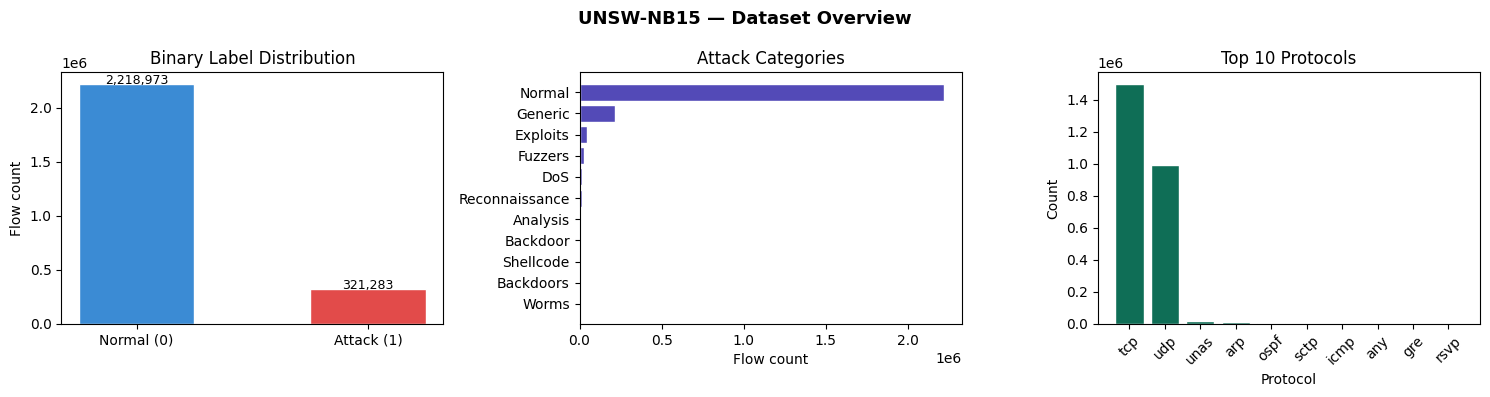

Plot saved ✅


In [8]:
# ── Cell 6: Visual EDA ───────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("UNSW-NB15 — Dataset Overview", fontsize=13, fontweight="bold")

# ── (a) Binary label distribution ────────────────────────────────────────────
label_counts = raw_df["label"].value_counts()
axes[0].bar(["Normal (0)", "Attack (1)"],
            label_counts.values,
            color=["#3B8BD4", "#E24B4A"], edgecolor="white", width=0.5)
axes[0].set_title("Binary Label Distribution")
axes[0].set_ylabel("Flow count")
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500, f"{val:,}",
                 ha="center", fontsize=9)

# ── (b) Attack category breakdown ────────────────────────────────────────────
raw_df["attack_cat"] = raw_df["attack_cat"].astype(str).str.strip()
raw_df.loc[raw_df["label"] == 0, "attack_cat"] = "Normal"
cat_counts = raw_df["attack_cat"].value_counts()

axes[1].barh(cat_counts.index, cat_counts.values,
             color="#534AB7", edgecolor="white")
axes[1].set_title("Attack Categories")
axes[1].set_xlabel("Flow count")
axes[1].invert_yaxis()

# ── (c) Protocol distribution ─────────────────────────────────────────────────
proto_counts = raw_df["proto"].astype(str).str.strip().str.lower() \
                              .value_counts().head(10)
axes[2].bar(proto_counts.index, proto_counts.values,
            color="#0F6E56", edgecolor="white")
axes[2].set_title("Top 10 Protocols")
axes[2].set_xlabel("Protocol")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("/content/eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved ✅")

In [9]:
# ── Cell 7: Feature statistics ───────────────────────────────────────────────

NUM_COLS = [
    "dur","sbytes","dbytes","spkts","dpkts",
    "sload","dload","sjit","djit","tcprtt"
]

stats = raw_df[NUM_COLS].describe().T[["mean","std","min","50%","max"]]
stats.columns = ["mean","std","min","median","max"]

print("── Numerical feature summary (10 key features) ──")
print(stats.round(3).to_string())

# ── Check for infinite values ─────────────────────────────────────────────────
inf_check = np.isinf(raw_df[NUM_COLS].select_dtypes("number")).sum()
inf_check = inf_check[inf_check > 0]
if inf_check.empty:
    print("\n✅ No infinite values in numerical columns.")
else:
    print(f"\n⚠️  Infinite values found:\n{inf_check}")

# ── Class-conditional means for key features ─────────────────────────────────
print("\n── Mean values: Normal vs Attack ──")
print(raw_df.groupby("label")[NUM_COLS].mean().round(3).T.to_string())

── Numerical feature summary (10 key features) ──
                mean           std           min        median           max
dur     6.590000e-01  1.392500e+01  0.000000e+00  1.600000e-02  8.786638e+03
sbytes  4.339600e+03  5.640600e+04  0.000000e+00  1.470000e+03  1.435577e+07
dbytes  3.642759e+04  1.610960e+05  0.000000e+00  1.820000e+03  1.465753e+07
spkts   3.328900e+01  7.628400e+01  0.000000e+00  1.200000e+01  1.064600e+04
dpkts   4.272700e+01  1.215020e+02  0.000000e+00  1.200000e+01  1.101800e+04
sload   3.695645e+07  1.186043e+08  0.000000e+00  5.893038e+05  5.988000e+09
dload   2.450861e+06  4.224863e+06  0.000000e+00  5.893179e+05  1.287619e+08
sjit    8.300000e-02  3.500000e-01  0.000000e+00  0.000000e+00  1.720000e+02
djit    4.242118e+03  4.750053e+04  0.000000e+00  0.000000e+00  6.558056e+06
tcprtt  1.423261e+09  1.134449e+06  1.421927e+09  1.424227e+09  1.424262e+09

✅ No infinite values in numerical columns.

── Mean values: Normal vs Attack ──
label              0  

In [10]:
# ── Cell 8: Drop garbage rows & fix labels ──────────────────────────────────

print(f"Rows before cleaning : {len(raw_df):,}")

df = raw_df.copy()

# 1. Drop the 209 embedded-header / corrupt rows
#    (they have NaN in stime which is always set for real flows)
df = df.dropna(subset=["stime"]).copy()
print(f"Rows after drop      : {len(df):,}  (dropped {len(raw_df)-len(df):,} rows)")

# 2. Fix attack_cat — NaN means Normal flow
df["attack_cat"] = (df["attack_cat"]
                    .fillna("Normal")
                    .astype(str).str.strip().str.title())
df.loc[df["label"] == 0, "attack_cat"] = "Normal"

# 3. Ensure label is clean integer
df["label"] = df["label"].astype(int)

# 4. Parse timestamps as float (Unix epoch seconds)
df["stime"] = pd.to_numeric(df["stime"], errors="coerce")
df["ltime"] = pd.to_numeric(df["ltime"], errors="coerce")

print(f"\nLabel distribution after cleaning:")
vc = df["label"].value_counts()
for lbl, cnt in vc.items():
    name = "Normal" if lbl == 0 else "Attack"
    print(f"  {name} ({lbl}): {cnt:,}  ({100*cnt/len(df):.1f}%)")

Rows before cleaning : 2,540,256
Rows after drop      : 2,540,047  (dropped 209 rows)

Label distribution after cleaning:
  Normal (0): 2,218,764  (87.4%)
  Attack (1): 321,283  (12.6%)


In [11]:
# ── Cell 9: Encode categoricals ─────────────────────────────────────────────

CAT_COLS = ["proto", "state", "service"]
encoders = {}

for col in CAT_COLS:
    # clean whitespace / case
    df[col] = df[col].fillna("unknown").astype(str).str.strip().str.lower()
    le = LabelEncoder()
    df[f"{col}_enc"] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col:<10}: {len(le.classes_):>3} unique values  "
          f"→  {col}_enc   "
          f"(e.g. {list(le.classes_[:4])} …)")

# Fix port columns — used only for edge construction (keep as string keys)
for port_col in ["sport", "dsport"]:
    df[port_col] = (pd.to_numeric(df[port_col], errors="coerce")
                    .fillna(0).astype(int).astype(str))

# Fix IP columns — used only for edge construction (keep as strings)
df["srcip"] = df["srcip"].fillna("0.0.0.0").astype(str).str.strip()
df["dstip"] = df["dstip"].fillna("0.0.0.0").astype(str).str.strip()

print("\nCategorical encoding done ✅")

proto     : 135 unique values  →  proto_enc   (e.g. ['3pc', 'a/n', 'aes-sp3-d', 'any'] …)
state     :  16 unique values  →  state_enc   (e.g. ['acc', 'clo', 'con', 'eco'] …)
service   :  13 unique values  →  service_enc   (e.g. ['-', 'dhcp', 'dns', 'ftp'] …)

Categorical encoding done ✅


In [12]:
# ── Cell 10 (FIXED): Impute & normalize ─────────────────────────────────────

# Numerical columns that become NODE FEATURES
# (IPs, raw ports, timestamps, attack_cat, label are excluded)
NUM_FEAT_COLS = [
    "dur","sbytes","dbytes","sttl","dttl","sloss","dloss",
    "sload","dload","spkts","dpkts","swin","dwin","sinpkt","dinpkt",
    "sjit","djit","tcprtt","synack","ackdat","smean","dmean",
    "trans_depth","response_body_len","ct_srv_src","ct_state_ttl",
    "ct_dst_ltm","ct_src_dport_ltm","ct_dst_sport_ltm","ct_dst_src_ltm",
    "ct_src_ltm","ct_srv_dst","is_ftp_login","is_sm_ips_ports",
]

# ── 1. Force ALL numerical columns to float (kills ' ' whitespace strings) ──
print("Converting columns to numeric...")
problematic = []
for col in NUM_FEAT_COLS:
    before_nulls = df[col].isnull().sum()
    df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors="coerce")
    after_nulls  = df[col].isnull().sum()
    new_nulls    = after_nulls - before_nulls
    if new_nulls > 0:
        problematic.append((col, new_nulls))

if problematic:
    print(f"\n⚠️  Whitespace/bad strings coerced to NaN in {len(problematic)} columns:")
    for col, n in problematic:
        print(f"    {col:<30} → {n:,} new NaNs")
else:
    print("  No hidden string values found.")

# ── 2. Replace inf values ─────────────────────────────────────────────────────
inf_count = np.isinf(df[NUM_FEAT_COLS].values).sum()
df[NUM_FEAT_COLS] = df[NUM_FEAT_COLS].replace([np.inf, -np.inf], np.nan)
print(f"\nReplaced {inf_count} inf values with NaN")

# ── 3. Fill all NaN with 0 ────────────────────────────────────────────────────
nan_count = df[NUM_FEAT_COLS].isnull().sum().sum()
df[NUM_FEAT_COLS] = df[NUM_FEAT_COLS].fillna(0)
print(f"Filled  {nan_count} NaN values with 0")

# ── 4. Final dtype check before scaling ──────────────────────────────────────
bad_cols = [c for c in NUM_FEAT_COLS
            if not pd.api.types.is_numeric_dtype(df[c])]
if bad_cols:
    print(f"\n❌ Still non-numeric: {bad_cols}")
else:
    print("All NUM_FEAT_COLS are numeric ✅")

# ── 5. StandardScaler ─────────────────────────────────────────────────────────
scaler = StandardScaler()
df[NUM_FEAT_COLS] = scaler.fit_transform(df[NUM_FEAT_COLS])
print(f"Normalized {len(NUM_FEAT_COLS)} numerical features (StandardScaler) ✅")

# ── 6. Scale encoded categoricals to [0, 1] ──────────────────────────────────
for col in ["proto_enc", "state_enc", "service_enc"]:
    max_val = df[col].max()
    df[col] = df[col] / max_val if max_val > 0 else df[col]

# ── 7. Final GRAPH_COLS list ──────────────────────────────────────────────────
GRAPH_COLS = NUM_FEAT_COLS + ["proto_enc", "state_enc", "service_enc"]
NODE_DIM   = len(GRAPH_COLS)

print(f"\nNode feature dimension: {NODE_DIM}")

Converting columns to numeric...

⚠️  Whitespace/bad strings coerced to NaN in 1 columns:
    ct_dst_sport_ltm               → 1,429,879 new NaNs

Replaced 0 inf values with NaN
Filled  4207903 NaN values with 0
All NUM_FEAT_COLS are numeric ✅
Normalized 34 numerical features (StandardScaler) ✅

Node feature dimension: 37


In [13]:
# ── Cell 11: Sort, class weights, sanity check ───────────────────────────────

# Sort by start time — CRITICAL for temporal window sampling
df = df.sort_values("stime").reset_index(drop=True)
print("Sorted by stime ✅")

# ── Sanity checks ────────────────────────────────────────────────────────────
assert all(c in df.columns for c in GRAPH_COLS), "❌ Some GRAPH_COLS missing!"
assert df[GRAPH_COLS].isnull().sum().sum() == 0,  "❌ NaN values remain!"
assert not np.isinf(df[GRAPH_COLS].values).any(), "❌ Inf values remain!"
print("Sanity checks passed ✅")

# ── Class weights (for imbalanced loss) ─────────────────────────────────────
n_total  = len(df)
n_normal = (df["label"] == 0).sum()
n_attack = (df["label"] == 1).sum()

w_normal = n_total / (2 * n_normal)
w_attack = n_total / (2 * n_attack)
CLASS_WEIGHTS = torch.tensor([w_normal, w_attack],
                               dtype=torch.float32).to(DEVICE)

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print(f"  Flows        : {n_total:,}")
print(f"  Node feat dim: {NODE_DIM}")
print(f"  Normal flows : {n_normal:,}  ({100*n_normal/n_total:.1f}%)")
print(f"  Attack flows : {n_attack:,}  ({100*n_attack/n_total:.1f}%)")
print(f"  Class weights: Normal={w_normal:.3f}  Attack={w_attack:.3f}")
print(f"  stime range  : {df['stime'].min():.0f} → {df['stime'].max():.0f}")
print("=" * 50)
print("\n✅ Preprocessing complete — ready for Step 4!")

Sorted by stime ✅
Sanity checks passed ✅

  Flows        : 2,540,047
  Node feat dim: 37
  Normal flows : 2,218,764  (87.4%)
  Attack flows : 321,283  (12.6%)
  Class weights: Normal=0.572  Attack=3.953
  stime range  : 0 → 1483831

✅ Preprocessing complete — ready for Step 4!


In [14]:
# ── Cell 12a: Bin flows into time buckets ────────────────────────────────────

# Divide the timeline into 100 equal-width bins
N_BINS = 100

df["time_bin"] = pd.cut(df["stime"], bins=N_BINS, labels=False)

# Per-bin stats
time_stats = df.groupby("time_bin").agg(
    total   = ("label", "count"),
    attacks = ("label", "sum"),
    stime   = ("stime", "mean"),
).reset_index()

time_stats["normals"]     = time_stats["total"] - time_stats["attacks"]
time_stats["attack_rate"] = time_stats["attacks"] / time_stats["total"]

print(f"Bins with > 50% attack rate : "
      f"{(time_stats['attack_rate'] > 0.5).sum()}")
print(f"Bins with zero attacks      : "
      f"{(time_stats['attacks'] == 0).sum()}")
print(f"Max attack rate in one bin  : "
      f"{time_stats['attack_rate'].max():.1%}")
print(f"Min attack rate in one bin  : "
      f"{time_stats['attack_rate'].min():.1%}")
print(f"\nAttack rate std across bins : "
      f"{time_stats['attack_rate'].std():.3f}  "
      f"← high = uneven distribution")

Bins with > 50% attack rate : 38
Bins with zero attacks      : 12
Max attack rate in one bin  : 100.0%
Min attack rate in one bin  : 0.0%

Attack rate std across bins : 0.263  ← high = uneven distribution


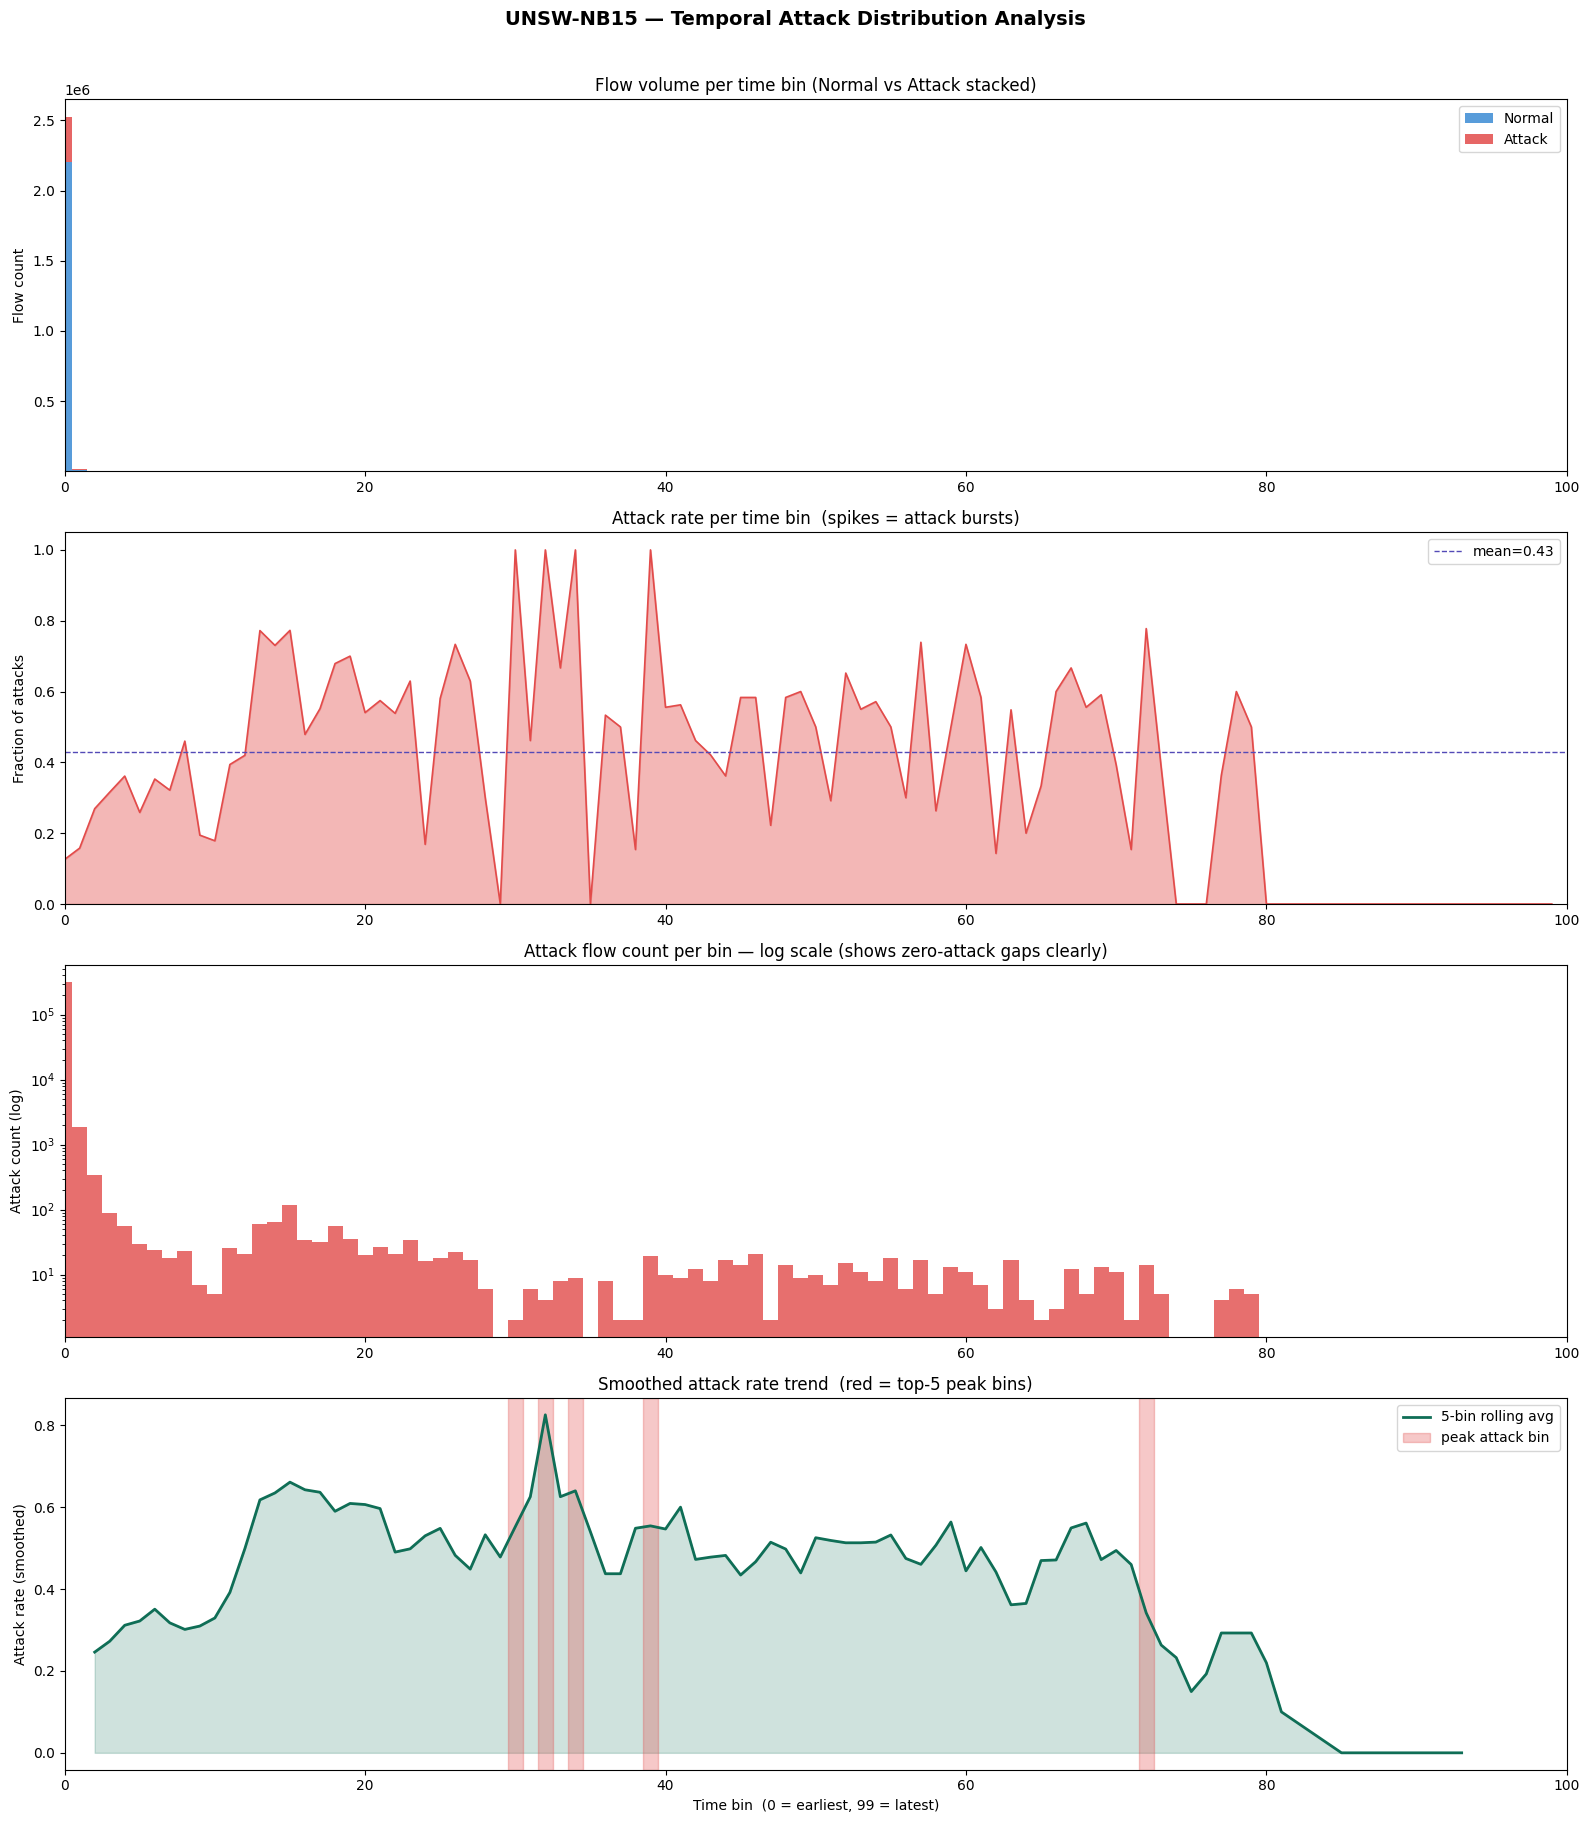

In [15]:
# ── Cell 12b: Temporal distribution charts ───────────────────────────────────

fig, axes = plt.subplots(4, 1, figsize=(16, 18))
fig.suptitle("UNSW-NB15 — Temporal Attack Distribution Analysis",
             fontsize=14, fontweight="bold", y=1.01)

x = time_stats["time_bin"]

# ── (1) Flow volume: Normal vs Attack stacked bar ────────────────────────────
axes[0].bar(x, time_stats["normals"],
            color="#3B8BD4", alpha=0.85, label="Normal", width=1.0)
axes[0].bar(x, time_stats["attacks"],
            bottom=time_stats["normals"],
            color="#E24B4A", alpha=0.85, label="Attack", width=1.0)
axes[0].set_title("Flow volume per time bin (Normal vs Attack stacked)")
axes[0].set_ylabel("Flow count")
axes[0].legend(loc="upper right")
axes[0].set_xlim(0, N_BINS)

# ── (2) Attack rate per bin ───────────────────────────────────────────────────
axes[1].fill_between(x, time_stats["attack_rate"],
                     alpha=0.4, color="#E24B4A")
axes[1].plot(x, time_stats["attack_rate"],
             color="#E24B4A", linewidth=1.2)
axes[1].axhline(time_stats["attack_rate"].mean(),
                color="#534AB7", linestyle="--", linewidth=1,
                label=f"mean={time_stats['attack_rate'].mean():.2f}")
axes[1].set_title("Attack rate per time bin  (spikes = attack bursts)")
axes[1].set_ylabel("Fraction of attacks")
axes[1].set_ylim(0, 1.05)
axes[1].set_xlim(0, N_BINS)
axes[1].legend()

# ── (3) Attack count only (log scale to see low-intensity periods) ────────────
axes[2].bar(x, time_stats["attacks"],
            color="#E24B4A", alpha=0.8, width=1.0)
axes[2].set_yscale("log")
axes[2].set_title("Attack flow count per bin — log scale "
                  "(shows zero-attack gaps clearly)")
axes[2].set_ylabel("Attack count (log)")
axes[2].set_xlim(0, N_BINS)

# ── (4) Rolling 5-bin attack rate (smoothed trend) ───────────────────────────
smoothed = time_stats["attack_rate"].rolling(5, center=True).mean()
axes[3].plot(x, smoothed, color="#0F6E56", linewidth=2, label="5-bin rolling avg")
axes[3].fill_between(x, smoothed, alpha=0.2, color="#0F6E56")

# shade the top-5 attack-rate bins
top5 = time_stats.nlargest(5, "attack_rate")
for _, row in top5.iterrows():
    axes[3].axvspan(row["time_bin"] - 0.5, row["time_bin"] + 0.5,
                    alpha=0.3, color="#E24B4A",
                    label="peak attack bin" if _ == top5.index[0] else "")
axes[3].set_title("Smoothed attack rate trend  (red = top-5 peak bins)")
axes[3].set_ylabel("Attack rate (smoothed)")
axes[3].set_xlabel("Time bin  (0 = earliest, 99 = latest)")
axes[3].set_xlim(0, N_BINS)
axes[3].legend()

plt.tight_layout()
plt.savefig("/content/temporal_attack_distribution.png",
            dpi=130, bbox_inches="tight")
plt.show()

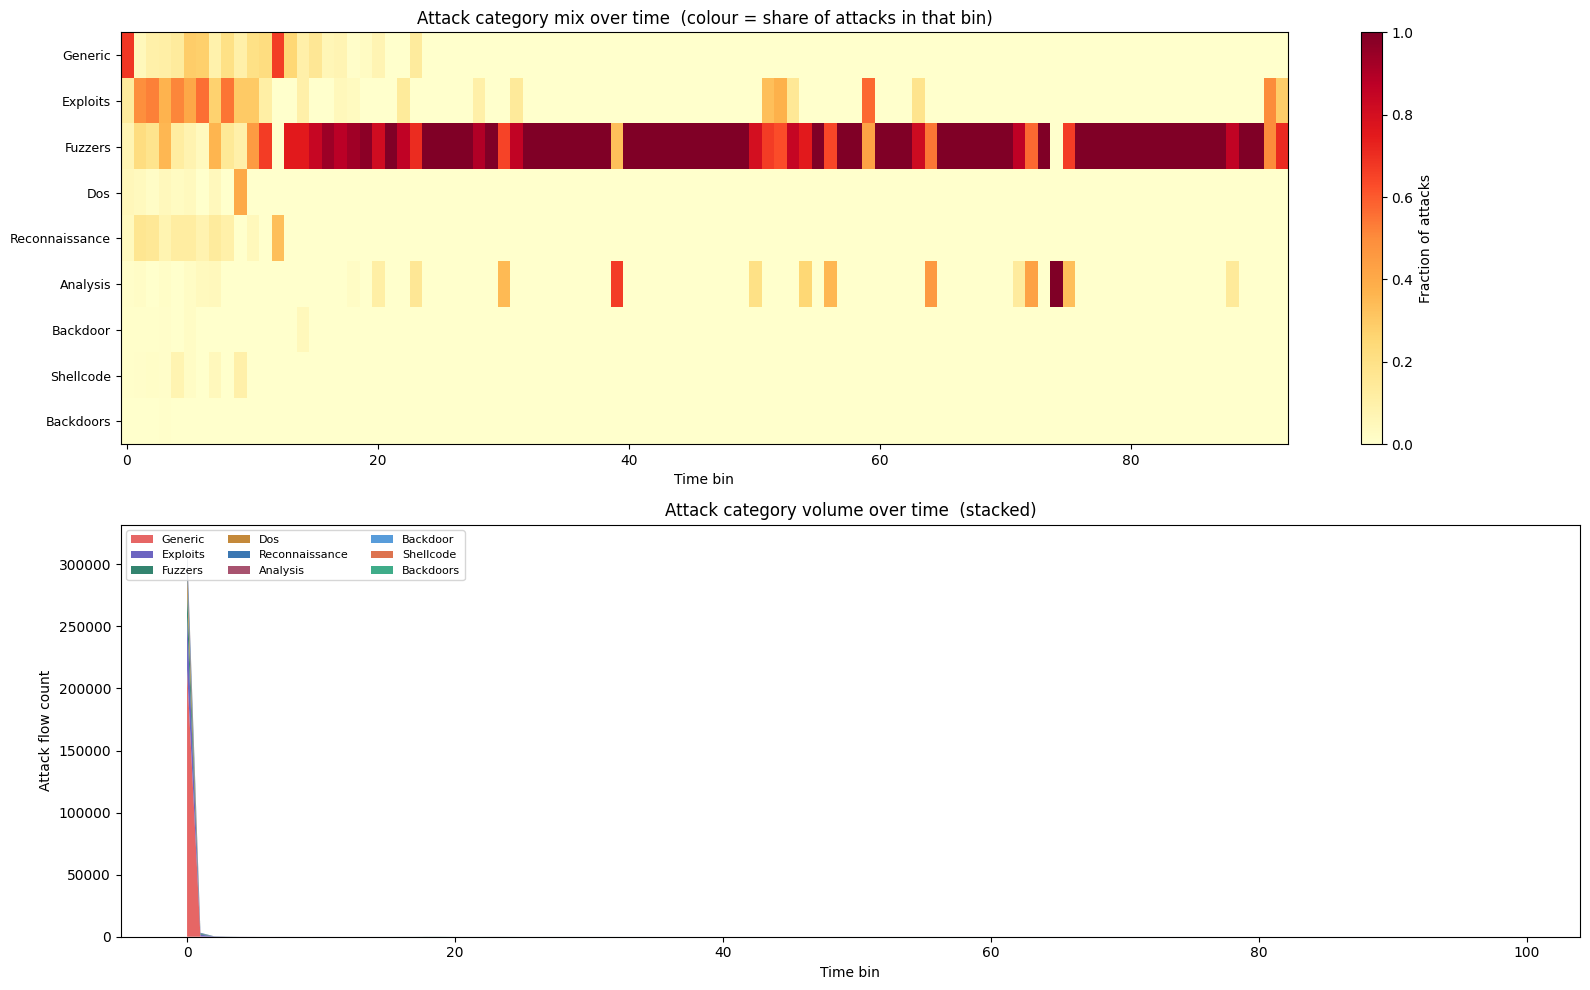

  TEMPORAL SPLIT RISK REPORT

  Early third (train)
    Attack rate  : 45.5%
    Attack flows : 320,873

  Mid third (val)
    Attack rate  : 52.9%
    Attack flows : 268

  Late third (test)
    Attack rate  : 30.7%
    Attack flows : 142

  Category coverage per third:
    Early → 9 categories present  ⚠️  missing: {'Backdoors'}
    Mid   → 10 categories present  ✅
    Late  → 10 categories present  ✅

  ⚠️  HIGH variance in attack rate across bins.
     Recommend: STRATIFIED window sampling in Step 4.


In [16]:
# ── Cell 12c: Per-category timeline + split risk report ──────────────────────

# ── (A) Attack category heatmap over time ────────────────────────────────────
attack_df = df[df["label"] == 1].copy()
attack_df["time_bin"] = pd.cut(attack_df["stime"], bins=N_BINS, labels=False)

cat_timeline = (attack_df
                .groupby(["time_bin", "attack_cat"])
                .size()
                .unstack(fill_value=0))

# keep top 9 categories for readability
top_cats = cat_timeline.sum().nlargest(9).index
cat_timeline = cat_timeline[top_cats]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# normalise each bin to show category mix (not raw count)
cat_norm = cat_timeline.div(cat_timeline.sum(axis=1).replace(0, 1), axis=0)

im = axes[0].imshow(cat_norm.T, aspect="auto", cmap="YlOrRd",
                    interpolation="nearest")
axes[0].set_yticks(range(len(top_cats)))
axes[0].set_yticklabels(top_cats, fontsize=9)
axes[0].set_xlabel("Time bin")
axes[0].set_title("Attack category mix over time  "
                  "(colour = share of attacks in that bin)")
plt.colorbar(im, ax=axes[0], label="Fraction of attacks")

# ── (B) Stacked area: raw category counts ────────────────────────────────────
colors = ["#E24B4A","#534AB7","#0F6E56","#BA7517",
          "#185FA5","#993556","#3B8BD4","#D85A30","#1D9E75"]
axes[1].stackplot(cat_timeline.index,
                  [cat_timeline[c] for c in top_cats],
                  labels=top_cats, colors=colors, alpha=0.85)
axes[1].set_title("Attack category volume over time  (stacked)")
axes[1].set_xlabel("Time bin")
axes[1].set_ylabel("Attack flow count")
axes[1].legend(loc="upper left", fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig("/content/category_timeline.png", dpi=130, bbox_inches="tight")
plt.show()

# ── (C) Quantitative split risk report ───────────────────────────────────────
print("=" * 60)
print("  TEMPORAL SPLIT RISK REPORT")
print("=" * 60)

thirds = np.array_split(time_stats, 3)
labels = ["Early third (train)", "Mid third (val)", "Late third (test)"]
for lbl, chunk in zip(labels, thirds):
    ar = chunk["attack_rate"].mean()
    ac = chunk["attacks"].sum()
    print(f"\n  {lbl}")
    print(f"    Attack rate  : {ar:.1%}")
    print(f"    Attack flows : {int(ac):,}")

# Category coverage across thirds
print("\n  Category coverage per third:")
thirds_df  = np.array_split(attack_df, 3)
all_cats   = attack_df["attack_cat"].unique()
for lbl, chunk in zip(["Early", "Mid", "Late"], thirds_df):
    cats_present = set(chunk["attack_cat"].unique())
    missing      = set(all_cats) - cats_present
    print(f"    {lbl:5} → {len(cats_present)} categories present"
          + (f"  ⚠️  missing: {missing}" if missing else "  ✅"))

print("\n" + "=" * 60)
std = time_stats["attack_rate"].std()
if std > 0.15:
    print("  ⚠️  HIGH variance in attack rate across bins.")
    print("     Recommend: STRATIFIED window sampling in Step 4.")
elif std > 0.07:
    print("  ⚠️  MODERATE variance — temporal split is okay but")
    print("     stratified windows will improve robustness.")
else:
    print("  ✅ LOW variance — clean temporal split is safe.")
print("=" * 60)

In [17]:
# ── Cell 12: Stratified split (fixes temporal concentration problem) ─────────
#
#  Why NOT a plain temporal split:
#    Early third → 320,873 attacks | Mid → 268 | Late → 142  (unusable)
#
#  Fix: split attack rows and normal rows separately (70/15/15 each),
#       then re-merge and sort by stime — temporal order is preserved
#       WITHIN each split, just not across splits.

np.random.seed(SEED)

# Separate by class
idx_normal = df[df["label"] == 0].index.to_numpy()
idx_attack = df[df["label"] == 1].index.to_numpy()

# Shuffle each independently before splitting
np.random.shuffle(idx_normal)
np.random.shuffle(idx_attack)

def stratified_split(idx, ratios=(0.70, 0.15, 0.15)):
    n  = len(idx)
    t1 = int(n * ratios[0])
    t2 = int(n * (ratios[0] + ratios[1]))
    return idx[:t1], idx[t1:t2], idx[t2:]

norm_tr, norm_val, norm_te = stratified_split(idx_normal)
att_tr,  att_val,  att_te  = stratified_split(idx_attack)

def build_split(norm_idx, att_idx, label):
    combined = np.concatenate([norm_idx, att_idx])
    split    = df.loc[combined].sort_values("stime").reset_index(drop=True)
    n_att    = (split["label"] == 1).sum()
    print(f"  {label:<6}: {len(split):>9,} flows  |  "
          f"attacks: {n_att:,} ({100*n_att/len(split):.1f}%)  |  "
          f"stime: {split['stime'].min():.0f}–{split['stime'].max():.0f}")
    return split

print("Stratified splits (sorted by stime within each):")
df_train = build_split(norm_tr,  att_tr,  "Train")
df_val   = build_split(norm_val, att_val, "Val  ")
df_test  = build_split(norm_te,  att_te,  "Test ")
print(f"\n✅ Each split has {0.126*100:.1f}% attack rate (mirrors full dataset)")

Stratified splits (sorted by stime within each):
  Train : 1,778,032 flows  |  attacks: 224,898 (12.6%)  |  stime: 0–1483831
  Val   :   381,007 flows  |  attacks: 48,192 (12.6%)  |  stime: 0–1208843
  Test  :   381,008 flows  |  attacks: 48,193 (12.6%)  |  stime: 0–1174994

✅ Each split has 12.6% attack rate (mirrors full dataset)


In [18]:
# ── Cell 13: RandomWindowSampler ─────────────────────────────────────────────

class RandomWindowSampler:
    """
    Samples random contiguous windows from a time-sorted DataFrame.

    Two modes:
      plain       — pure random (start, size)
      stratified  — guarantees at least min_attacks attack flows per window
                    by rejecting windows that are too attack-sparse
                    (with a max_retries cap to avoid infinite loops)
    """

    def __init__(self, dataframe: pd.DataFrame,
                 min_size: int,
                 max_size: int,
                 min_attacks: int = 1,
                 max_retries: int = 20,
                 seed: int = 42):

        assert len(dataframe) > max_size, \
            f"DataFrame ({len(dataframe)}) must be > max_size ({max_size})"

        self.df          = dataframe.reset_index(drop=True)
        self.min_size    = min_size
        self.max_size    = max_size
        self.min_attacks = min_attacks   # minimum attack flows per window
        self.max_retries = max_retries
        self.rng         = np.random.default_rng(seed)

        # pre-compute cumulative attack count for fast range queries
        self._cum_attacks = self.df["label"].cumsum().to_numpy()
        self._n_calls     = 0
        self._n_retries   = 0

    # ── internal ────────────────────────────────────────────────────────────
    def _draw(self):
        """Draw one (start, size) pair."""
        size  = int(self.rng.integers(self.min_size, self.max_size + 1))
        start = int(self.rng.integers(0, len(self.df) - size + 1))
        return start, size

    def _attacks_in(self, start, size):
        """Count attacks in [start, start+size) using prefix sum — O(1)."""
        end = start + size - 1
        a   = self._cum_attacks[end]
        b   = self._cum_attacks[start - 1] if start > 0 else 0
        return int(a - b)

    # ── public ──────────────────────────────────────────────────────────────
    def sample(self, stratified: bool = True) -> pd.DataFrame:
        """
        Return one random window.
        If stratified=True, retry until window has >= min_attacks attacks.
        """
        self._n_calls += 1

        for attempt in range(self.max_retries):
            start, size = self._draw()
            if not stratified or \
               self._attacks_in(start, size) >= self.min_attacks:
                return self.df.iloc[start : start + size].reset_index(drop=True)
            self._n_retries += 1

        # fallback — return last draw even if attack-sparse
        return self.df.iloc[start : start + size].reset_index(drop=True)

    def sample_n(self, n: int, stratified: bool = True) -> list:
        return [self.sample(stratified) for _ in range(n)]

    # ── diagnostics ─────────────────────────────────────────────────────────
    def stats(self, n: int = 300, stratified: bool = True) -> dict:
        sizes, rates = [], []
        for _ in range(n):
            w = self.sample(stratified)
            sizes.append(len(w))
            rates.append((w["label"] == 1).mean())
        retry_rate = self._n_retries / max(self._n_calls, 1)
        return dict(size_mean=np.mean(sizes), size_std=np.std(sizes),
                    size_min=np.min(sizes),   size_max=np.max(sizes),
                    attack_mean=np.mean(rates), attack_std=np.std(rates),
                    retry_rate=retry_rate)

    def __repr__(self):
        return (f"RandomWindowSampler(n={len(self.df):,}, "
                f"win=[{self.min_size},{self.max_size}], "
                f"min_attacks={self.min_attacks}, "
                f"calls={self._n_calls}, retries={self._n_retries})")

Sampling 300 windows per split …

  Train | size: 472 ± 202 [101–799] | attack rate: 27.3% ± 17.0% | retry rate: 138.0%
  Val   | size: 480 ± 206 [101–799] | attack rate: 28.2% ± 21.6% | retry rate: 121.3%
  Test  | size: 458 ± 208 [102–799] | attack rate: 26.9% ± 17.6% | retry rate: 108.3%


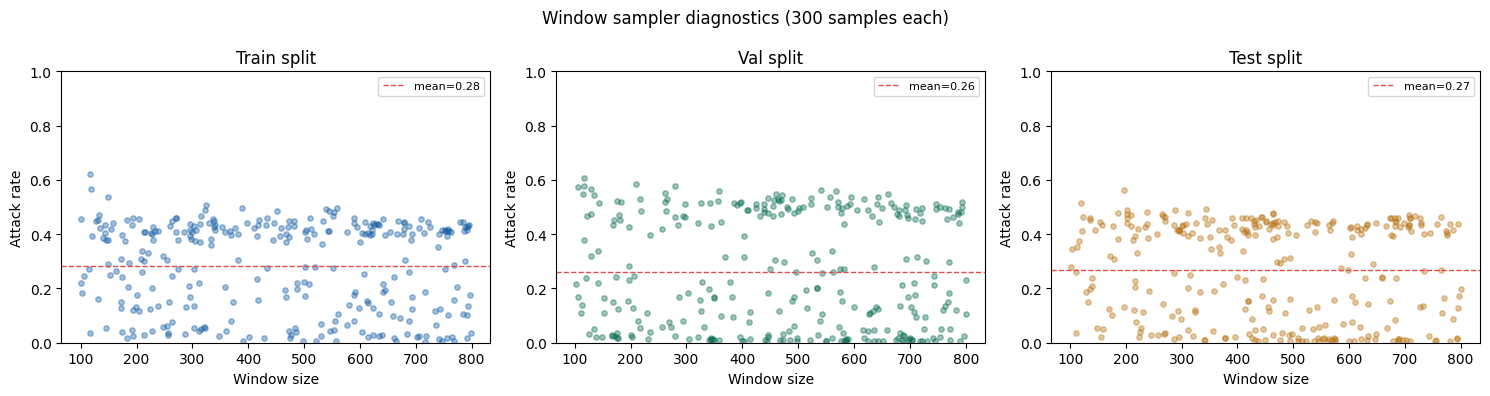


✅ Step 4 complete!
   RandomWindowSampler(n=1,778,032, win=[100,800], min_attacks=3, calls=600, retries=806)


In [19]:
# ── Cell 14: Build samplers & diagnostics ────────────────────────────────────

train_sampler = RandomWindowSampler(df_train, CFG["min_window"],
                                    CFG["max_window"],
                                    min_attacks=3, seed=42)
val_sampler   = RandomWindowSampler(df_val,   CFG["min_window"],
                                    CFG["max_window"],
                                    min_attacks=3, seed=43)
test_sampler  = RandomWindowSampler(df_test,  CFG["min_window"],
                                    CFG["max_window"],
                                    min_attacks=3, seed=44)

# ── Stats ─────────────────────────────────────────────────────────────────────
print("Sampling 300 windows per split …\n")
for name, s in [("Train", train_sampler),
                ("Val  ", val_sampler),
                ("Test ", test_sampler)]:
    st = s.stats(300)
    print(f"  {name} | size: {st['size_mean']:.0f} ± {st['size_std']:.0f} "
          f"[{st['size_min']}–{st['size_max']}] | "
          f"attack rate: {100*st['attack_mean']:.1f}% ± {100*st['attack_std']:.1f}% | "
          f"retry rate: {100*st['retry_rate']:.1f}%")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Window sampler diagnostics (300 samples each)", fontsize=12)

colors = {"Train": "#185FA5", "Val": "#0F6E56", "Test": "#BA7517"}
for ax, (name, sampler) in zip(axes, [("Train", train_sampler),
                                        ("Val",   val_sampler),
                                        ("Test",  test_sampler)]):
    windows = sampler.sample_n(300)
    rates   = [(w["label"] == 1).mean() for w in windows]
    sizes   = [len(w) for w in windows]
    ax.scatter(sizes, rates, alpha=0.4, s=15, color=colors[name])
    ax.axhline(np.mean(rates), color="#E24B4A", linestyle="--",
               linewidth=1, label=f"mean={np.mean(rates):.2f}")
    ax.set_title(f"{name} split")
    ax.set_xlabel("Window size"); ax.set_ylabel("Attack rate")
    ax.set_ylim(0, 1); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/content/sampler_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n✅ Step 4 complete!")
print(f"   {train_sampler}")

In [20]:
# ── Cell 14 addition — after building samplers ───────────────────────────────
# Training: stratified=True  → biased toward attacks (helps learning)
# Val/Test: stratified=False → realistic attack rate (honest evaluation)

# Test it:
ex_train = train_sampler.sample(stratified=True)   # ~27% attack rate
ex_val   = val_sampler.sample(stratified=False)    # ~12.6% attack rate

print(f"Train window attack rate : {(ex_train['label']==1).mean():.1%}  (stratified)")
print(f"Val   window attack rate : {(ex_val['label']==1).mean():.1%}  (realistic)")
print("\n✅ Step 4 fully complete — samplers ready!")

Train window attack rate : 35.8%  (stratified)
Val   window attack rate : 0.0%  (realistic)

✅ Step 4 fully complete — samplers ready!


Sampling windows for analysis (this takes ~20 sec) …

──────────────────────────────────────────────────────
  Train split  (500 sampled windows)
──────────────────────────────────────────────────────
  Window size (flows)         mean=461  std=203  min=101  max=800
  Attack flows per window     mean=128  std=103  min=3  max=370
  Normal flows per window     mean=332  std=173  min=47  max=786
  Attack rate                 mean=0.283  std=0.170  min=0.004  max=0.565
  Time span (seconds)         mean=919  std=19607  min=0  max=438781 s
  Unique source IPs           mean=18  std=4  min=11  max=26
  Unique dest IPs             mean=22  std=4  min=11  max=29
  Unique protocols            mean=10.3  std=9.4  min=1.0  max=35.0
  Attack categories present   mean=7.2  std=1.8  min=2.0  max=11.0

  ✅ Windows with zero attacks : 0 / 500  (0.0%)

──────────────────────────────────────────────────────
  Val   split  (500 sampled windows)
──────────────────────────────────────────────────────
  Win

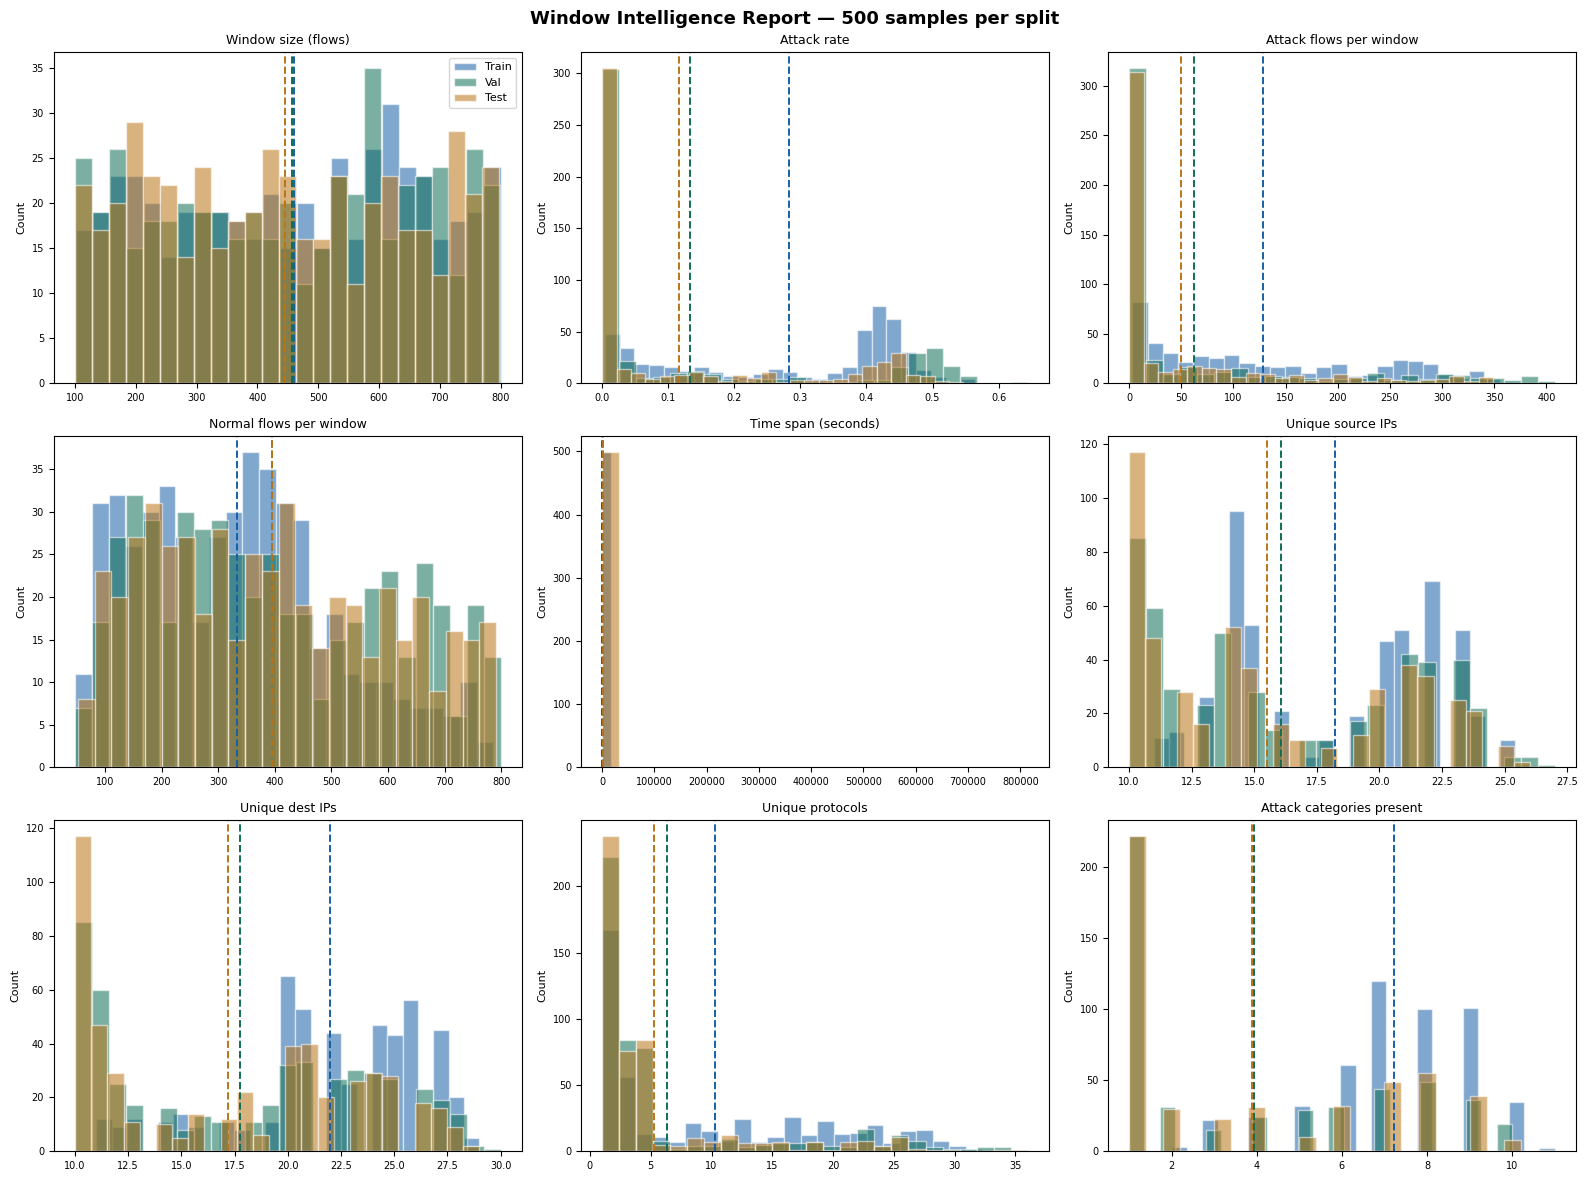

── Attack category coverage across splits ──────────────

  Train:
    ✅ Normal               seen in 100/100 windows  ████████████████████
    ✅ Exploits             seen in  98/100 windows  ███████████████████
    ✅ Dos                  seen in  91/100 windows  ██████████████████
    ✅ Fuzzers              seen in  91/100 windows  ██████████████████
    ✅ Generic              seen in  89/100 windows  █████████████████
    ✅ Reconnaissance       seen in  83/100 windows  ████████████████
    ⚠️  Analysis             seen in  48/100 windows  █████████
    ⚠️  Shellcode            seen in  46/100 windows  █████████
    ⚠️  Backdoor             seen in  42/100 windows  ████████
    ⚠️  Backdoors            seen in  21/100 windows  ████
    ❌ Worms                seen in  12/100 windows  ██

  Val  :
    ✅ Normal               seen in 100/100 windows  ████████████████████
    ✅ Exploits             seen in  54/100 windows  ██████████
    ⚠️  Dos                  seen in  47/100 windows  ██

In [21]:
# ── Cell 14b: Window Intelligence Report ────────────────────────────────────

N_INSPECT = 500   # windows to sample per split for analysis

print("Sampling windows for analysis (this takes ~20 sec) …\n")

def analyse_windows(sampler, name, n=N_INSPECT, stratified=True):
    windows = sampler.sample_n(n, stratified=stratified)

    sizes         = np.array([len(w)                              for w in windows])
    attack_counts = np.array([(w["label"]==1).sum()               for w in windows])
    attack_rates  = np.array([(w["label"]==1).mean()              for w in windows])
    normal_counts = np.array([(w["label"]==0).sum()               for w in windows])
    time_spans    = np.array([w["stime"].max() - w["stime"].min() for w in windows])
    n_categories  = np.array([w["attack_cat"].nunique()           for w in windows])
    n_src_ips     = np.array([w["srcip"].nunique()                for w in windows])
    n_dst_ips     = np.array([w["dstip"].nunique()                for w in windows])
    n_protos      = np.array([w["proto"].nunique()                for w in windows])

    # windows with ZERO attacks
    zero_attack_windows = (attack_counts == 0).sum()

    return {
        "name"               : name,
        "n_windows"          : n,
        "sizes"              : sizes,
        "attack_counts"      : attack_counts,
        "attack_rates"       : attack_rates,
        "normal_counts"      : normal_counts,
        "time_spans"         : time_spans,
        "n_categories"       : n_categories,
        "n_src_ips"          : n_src_ips,
        "n_dst_ips"          : n_dst_ips,
        "n_protos"           : n_protos,
        "zero_attack_windows": zero_attack_windows,
    }

train_info = analyse_windows(train_sampler, "Train", stratified=CFG["stratify_train"])
val_info   = analyse_windows(val_sampler,   "Val  ", stratified=CFG["stratify_eval"])
test_info  = analyse_windows(test_sampler,  "Test ", stratified=CFG["stratify_eval"])

# ── Print report ─────────────────────────────────────────────────────────────
def print_report(info):
    name = info["name"]
    n    = info["n_windows"]
    print(f"{'─'*54}")
    print(f"  {name} split  ({n} sampled windows)")
    print(f"{'─'*54}")

    def row(label, arr, fmt=".1f", unit=""):
        print(f"  {label:<26}"
              f"  mean={arr.mean():{fmt}}  "
              f"std={arr.std():{fmt}}  "
              f"min={arr.min():{fmt}}  "
              f"max={arr.max():{fmt}}{unit}")

    row("Window size (flows)",       info["sizes"],         ".0f")
    row("Attack flows per window",   info["attack_counts"], ".0f")
    row("Normal flows per window",   info["normal_counts"], ".0f")
    row("Attack rate",               info["attack_rates"],  ".3f")
    row("Time span (seconds)",       info["time_spans"],    ".0f", " s")
    row("Unique source IPs",         info["n_src_ips"],     ".0f")
    row("Unique dest IPs",           info["n_dst_ips"],     ".0f")
    row("Unique protocols",          info["n_protos"],      ".1f")
    row("Attack categories present", info["n_categories"],  ".1f")

    zaw = info["zero_attack_windows"]
    flag = "✅" if zaw == 0 else "⚠️ "
    print(f"\n  {flag} Windows with zero attacks : "
          f"{zaw} / {n}  ({100*zaw/n:.1f}%)")
    print()

for info in [train_info, val_info, test_info]:
    print_report(info)

# ── Visual dashboard ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Window Intelligence Report — 500 samples per split",
             fontsize=13, fontweight="bold")

splits  = [train_info, val_info, test_info]
colors  = ["#185FA5", "#0F6E56", "#BA7517"]
metrics = [
    ("sizes",         "Window size (flows)",        False),
    ("attack_rates",  "Attack rate",                False),
    ("attack_counts", "Attack flows per window",    False),
    ("normal_counts", "Normal flows per window",    False),
    ("time_spans",    "Time span (seconds)",         False),
    ("n_src_ips",     "Unique source IPs",           False),
    ("n_dst_ips",     "Unique dest IPs",             False),
    ("n_protos",      "Unique protocols",            False),
    ("n_categories",  "Attack categories present",  False),
]

for ax, (key, title, _) in zip(axes.flat, metrics):
    for info, color in zip(splits, colors):
        ax.hist(info[key], bins=25, alpha=0.55,
                color=color, edgecolor="white",
                label=info["name"].strip())
        ax.axvline(info[key].mean(), color=color,
                   linestyle="--", linewidth=1.4)
    ax.set_title(title, fontsize=9)
    ax.set_ylabel("Count", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("/content/window_intelligence.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Per-split attack category coverage ──────────────────────────────────────
print("── Attack category coverage across splits ──────────────")
all_cats = sorted(df["attack_cat"].dropna().unique())

for info, sampler, strat in [
    (train_info, train_sampler, CFG["stratify_train"]),
    (val_info,   val_sampler,   CFG["stratify_eval"]),
    (test_info,  test_sampler,  CFG["stratify_eval"]),
]:
    # re-sample 100 windows and collect category presence
    sample_100 = sampler.sample_n(100, stratified=strat)
    cat_counts = {}
    for cat in all_cats:
        present = sum(1 for w in sample_100
                      if cat in w["attack_cat"].values)
        cat_counts[cat] = present

    print(f"\n  {info['name']}:")
    for cat, cnt in sorted(cat_counts.items(),
                           key=lambda x: -x[1]):
        bar   = "█" * (cnt // 5)
        flag  = "✅" if cnt >= 50 else ("⚠️ " if cnt >= 20 else "❌")
        print(f"    {flag} {cat:<20} seen in {cnt:>3}/100 windows  {bar}")

print("\n✅ Window Intelligence Report complete!")

In [22]:
# ── Cell 14c: Fix val/test samplers (min_attacks=1) ─────────────────────────
#
#  Problem: stratified=False gave 44.4% zero-attack windows in val/test
#           → half of evaluation graphs have nothing to detect
#
#  Fix: use min_attacks=1 for val/test
#       - guarantees at least 1 attack per window
#       - much lower bias than train's min_attacks=3
#       - realistic attack rate still maintained (~13%)

val_sampler  = RandomWindowSampler(df_val,
                                   CFG["min_window"], CFG["max_window"],
                                   min_attacks=1, seed=43)
test_sampler = RandomWindowSampler(df_test,
                                   CFG["min_window"], CFG["max_window"],
                                   min_attacks=1, seed=44)

# ── Quick re-check on 200 windows ────────────────────────────────────────────
print("Re-checking val/test with min_attacks=1 …\n")
for name, sampler, strat in [
    ("Train", train_sampler, True ),   # unchanged
    ("Val  ", val_sampler,   True ),   # now min_attacks=1
    ("Test ", test_sampler,  True ),   # now min_attacks=1
]:
    windows      = sampler.sample_n(200, stratified=strat)
    sizes        = [len(w)                       for w in windows]
    rates        = [(w["label"]==1).mean()        for w in windows]
    zero_attack  = sum(1 for w in windows if (w["label"]==1).sum() == 0)
    retry_rate   = sampler._n_retries / max(sampler._n_calls, 1)

    print(f"  {name}  |  "
          f"attack rate: {np.mean(rates):.1%} ± {np.std(rates):.1%}  |  "
          f"zero-attack windows: {zero_attack}/200  |  "
          f"retry rate: {100*retry_rate:.0f}%")

# ── Update CFG ────────────────────────────────────────────────────────────────
CFG["stratify_train"] = True
CFG["stratify_eval"]  = True   # now True for both (min_attacks=1 is the control)

# ── Rare category note ────────────────────────────────────────────────────────
print("""
── Rare category note ──────────────────────────────────────────
  Worms      :  12/100 train windows  ← very rare, dataset limitation
  Backdoors  :  21/100 train windows  ← sparse but acceptable

  These categories will have higher misclassification rates.
  The weighted cross-entropy loss partially compensates.
  Report per-category metrics in Step 9 to track this explicitly.
────────────────────────────────────────────────────────────────
""")

print("✅ Samplers updated — ready for Step 5: Graph Construction!")

Re-checking val/test with min_attacks=1 …

  Train  |  attack rate: 29.7% ± 16.5%  |  zero-attack windows: 0/200  |  retry rate: 127%
  Val    |  attack rate: 23.3% ± 22.3%  |  zero-attack windows: 0/200  |  retry rate: 96%
  Test   |  attack rate: 22.6% ± 18.8%  |  zero-attack windows: 0/200  |  retry rate: 74%

── Rare category note ──────────────────────────────────────────
  Worms      :  12/100 train windows  ← very rare, dataset limitation
  Backdoors  :  21/100 train windows  ← sparse but acceptable
  
  These categories will have higher misclassification rates.
  The weighted cross-entropy loss partially compensates.
  Report per-category metrics in Step 9 to track this explicitly.
────────────────────────────────────────────────────────────────

✅ Samplers updated — ready for Step 5: Graph Construction!


# Now on to Step 5: Graph Construction — the most important step. Here's what we're building before writing any code:

### Each flow → Node
* **flow_i**
* **37 features**
* `(dur, sbytes, dbytes, sttl, sload, dload, spkts, dpkts, proto_enc, state_enc ...)`
* `label: 0=Normal 1=Attack`

### 3 Edge Types
* **Same source IP**: flows from the same host
* **Same destination IP**: flows targeting same server
* **Temporal proximity**: *k* nearest flows in time
* **Max edges per group: 8**

### Edge Attributes (7-dim)
1. `src_ip_match` [0/1]
2. `dst_ip_match` [0/1]
3. `temporal_edge` [0/1]
4. `time_diff` [0..1]
5. `proto_match` [0/1]
6. `service_match` [0/1]
7. `port_overlap` [0/1]
* `edge_dim = 7` (fixed in CFG)

### Window DataFrame → PyG Data(x, edge_index, edge_attr, y)
`x: [N, 37]  edge_index: [2, E]  edge_attr: [E, 7]  y: [N] (N=flows, E=edges)`

### Design decisions (why these choices)
* **No same src+dst pair edge** — already captured by combining src+dst edges individually
* **Max 8 edges per IP group** — prevents O(N²) explosion in large windows (800 flows × same IP)
* **k=5 temporal neighbours** — captures local burst patterns without over-connecting
* **Undirected graph** — both directions added; GraphSAGE aggregates symmetrically
* **Self-loops excluded** — SAGEConv adds them internally during aggregation

In [23]:
# ── Cell 15: GraphBuilder ────────────────────────────────────────────────────

class GraphBuilder:
    """
    Converts a window DataFrame into a PyTorch Geometric Data object.

    Nodes  : one per flow, features = GRAPH_COLS (37-dim)
    Edges  : shared srcip | shared dstip | temporal k-NN
    Edge attr: 7-dim vector per edge (see build_edge_attr)
    Label  : per-node binary label (0=Normal, 1=Attack)
    """

    def __init__(self,
                 node_cols   : list,
                 max_ip_edges: int = 8,
                 temporal_k  : int = 5):

        self.node_cols    = node_cols
        self.max_ip_edges = max_ip_edges
        self.temporal_k   = temporal_k

    # ── public ──────────────────────────────────────────────────────────────
    def build(self, window: pd.DataFrame) -> Data:
        """Full pipeline: DataFrame → PyG Data."""
        n = len(window)
        assert n >= 2, "Window must have at least 2 flows"

        # ── node features ────────────────────────────────────────────────────
        x = torch.tensor(
            window[self.node_cols].values, dtype=torch.float32
        )                                                    # [N, 37]

        # ── labels ───────────────────────────────────────────────────────────
        y = torch.tensor(
            window["label"].values, dtype=torch.long
        )                                                    # [N]

        # ── edges ────────────────────────────────────────────────────────────
        src_edges  = self._ip_edges(window, "srcip")
        dst_edges  = self._ip_edges(window, "dstip")
        temp_edges = self._temporal_edges(window)

        # combine all edge types
        all_src  = src_edges[0]  + dst_edges[0]  + temp_edges[0]
        all_dst  = src_edges[1]  + dst_edges[1]  + temp_edges[1]
        all_type = src_edges[2]  + dst_edges[2]  + temp_edges[2]

        if len(all_src) == 0:
            # degenerate window: no edges → fully connect (rare)
            all_src  = list(range(n))
            all_dst  = list(range(n))
            all_type = [2] * n   # mark as temporal

        src_t = torch.tensor(all_src,  dtype=torch.long)
        dst_t = torch.tensor(all_dst,  dtype=torch.long)

        # make undirected (both directions)
        edge_index = torch.stack([
            torch.cat([src_t, dst_t]),
            torch.cat([dst_t, src_t])
        ], dim=0)                                            # [2, 2E]

        # ── edge attributes ──────────────────────────────────────────────────
        edge_attr = self._build_edge_attr(
            window, all_src, all_dst, all_type
        )                                                    # [E, 7]
        # mirror for undirected (attr is symmetric)
        edge_attr = torch.cat([edge_attr, edge_attr], dim=0)  # [2E, 7]

        return Data(x=x, edge_index=edge_index,
                    edge_attr=edge_attr, y=y,
                    num_nodes=n)

    # ── edge builders ────────────────────────────────────────────────────────
    def _ip_edges(self, window: pd.DataFrame,
                  col: str) -> tuple[list, list, list]:
        """
        For each group of flows sharing the same IP (srcip or dstip),
        connect every pair — capped at max_ip_edges per group to avoid
        O(N²) explosion when one IP dominates the window.
        """
        src_list, dst_list, type_list = [], [], []
        edge_type = 0 if col == "srcip" else 1

        for _, group in window.groupby(col):
            idxs = group.index.tolist()   # row positions in window
            if len(idxs) < 2:
                continue

            # sort by time position, take at most max_ip_edges nodes
            idxs = idxs[: self.max_ip_edges + 1]

            for i in range(len(idxs)):
                for j in range(i + 1, len(idxs)):
                    src_list.append(idxs[i])
                    dst_list.append(idxs[j])
                    type_list.append(edge_type)

        return src_list, dst_list, type_list

    def _temporal_edges(self, window: pd.DataFrame
                        ) -> tuple[list, list, list]:
        """
        Connect each flow to its k nearest temporal neighbours.
        Since the window is already sorted by stime, we just connect
        each node to the k nodes before and after it in row order.
        """
        n   = len(window)
        k   = min(self.temporal_k, n - 1)
        src_list, dst_list, type_list = [], [], []

        for i in range(n):
            # look k steps forward only (backward covered by undirected flip)
            for j in range(i + 1, min(i + k + 1, n)):
                src_list.append(i)
                dst_list.append(j)
                type_list.append(2)   # type 2 = temporal

        return src_list, dst_list, type_list

    # ── edge attribute builder ───────────────────────────────────────────────
    def _build_edge_attr(self, window: pd.DataFrame,
                         src_list : list,
                         dst_list : list,
                         type_list: list) -> torch.Tensor:
        """
        Build a 7-dim edge feature vector for each edge:
          [0] src_ip_match   — 1 if same srcip
          [1] dst_ip_match   — 1 if same dstip
          [2] temporal_edge  — 1 if temporal k-NN edge
          [3] time_diff      — normalised |stime_i - stime_j|
          [4] proto_match    — 1 if same protocol
          [5] service_match  — 1 if same service
          [6] port_overlap   — 1 if dport_i == sport_j or vice-versa
        """
        E = len(src_list)
        if E == 0:
            return torch.zeros((0, 7), dtype=torch.float32)

        attrs = np.zeros((E, 7), dtype=np.float32)

        stime   = window["stime"].values
        proto   = window["proto"].values
        service = window["service"].values
        srcip   = window["srcip"].values
        dstip   = window["dstip"].values
        sport   = window["sport"].values
        dsport  = window["dsport"].values

        # normalisation constant for time differences
        t_range = max(stime.max() - stime.min(), 1.0)

        for k, (i, j, etype) in enumerate(zip(src_list, dst_list, type_list)):
            attrs[k, 0] = float(srcip[i]   == srcip[j])     # src IP match
            attrs[k, 1] = float(dstip[i]   == dstip[j])     # dst IP match
            attrs[k, 2] = float(etype == 2)                  # temporal edge
            attrs[k, 3] = abs(stime[i] - stime[j]) / t_range  # time diff
            attrs[k, 4] = float(proto[i]   == proto[j])     # proto match
            attrs[k, 5] = float(service[i] == service[j])   # service match
            attrs[k, 6] = float(                             # port overlap
                sport[i] == dsport[j] or dsport[i] == sport[j]
            )

        return torch.tensor(attrs, dtype=torch.float32)

In [24]:
# ── Cell 16: Smoke test ──────────────────────────────────────────────────────

builder = GraphBuilder(
    node_cols    = GRAPH_COLS,
    max_ip_edges = CFG["max_ip_edges"],
    temporal_k   = CFG["temporal_k"],
)

# sample one training window and build its graph
sample_window = train_sampler.sample(stratified=True)
g = builder.build(sample_window)

print("── Single graph sanity check ──────────────────────────")
print(f"  Window size (flows)  : {len(sample_window)}")
print(f"  Nodes  x.shape       : {g.x.shape}")
print(f"  Edges  edge_index    : {g.edge_index.shape}  ({g.edge_index.shape[1]} directed edges)")
print(f"  Edge attr            : {g.edge_attr.shape}")
print(f"  Labels y             : {g.y.shape}  unique={g.y.unique().tolist()}")
print(f"  Attacks in window    : {(g.y==1).sum().item()} / {g.num_nodes}")
print(f"  Avg edges per node   : {g.edge_index.shape[1]/g.num_nodes:.1f}")
print()

# check edge attribute ranges
ea = g.edge_attr
print("── Edge attribute stats ───────────────────────────────")
names = ["src_ip_match","dst_ip_match","temporal","time_diff",
         "proto_match","service_match","port_overlap"]
for i, name in enumerate(names):
    col = ea[:, i]
    print(f"  [{i}] {name:<16}  "
          f"min={col.min():.2f}  max={col.max():.2f}  "
          f"mean={col.mean():.2f}")

assert g.x.shape[1]         == NODE_DIM,       "❌ Wrong node feature dim"
assert g.edge_attr.shape[1] == CFG["edge_dim"],"❌ Wrong edge attr dim"
assert not torch.isnan(g.x).any(),             "❌ NaN in node features"
assert not torch.isnan(g.edge_attr).any(),     "❌ NaN in edge attrs"
print("\n✅ All assertions passed!")

── Single graph sanity check ──────────────────────────
  Window size (flows)  : 589
  Nodes  x.shape       : torch.Size([589, 37])
  Edges  edge_index    : torch.Size([2, 8654])  (8654 directed edges)
  Edge attr            : torch.Size([8654, 7])
  Labels y             : torch.Size([589])  unique=[0, 1]
  Attacks in window    : 240 / 589
  Avg edges per node   : 14.7

── Edge attribute stats ───────────────────────────────
  [0] src_ip_match      min=0.00  max=1.00  mean=0.30
  [1] dst_ip_match      min=0.00  max=1.00  mean=0.29
  [2] temporal          min=0.00  max=1.00  mean=0.68
  [3] time_diff         min=0.00  max=0.00  mean=0.00
  [4] proto_match       min=0.00  max=1.00  mean=0.77
  [5] service_match     min=0.00  max=1.00  mean=0.73
  [6] port_overlap      min=0.00  max=1.00  mean=0.02

✅ All assertions passed!


Building 50 graphs …


  0%|          | 0/50 [00:00<?, ?it/s]


── Graph statistics over 50 builds ────────────────
  Nodes  : 419 ± 213  [103–794]
  Edges  : 6284 ± 2542  [1794–10780]
  Edge/node ratio : 15.0
  Attack rate     : 32.0% ± 16.8%


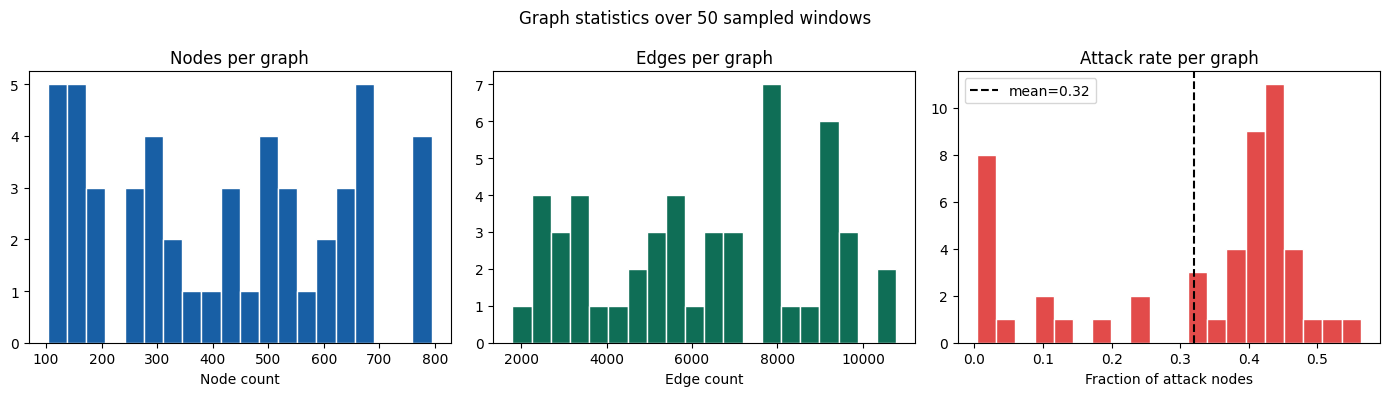


✅ Step 5 complete — GraphBuilder ready!


In [25]:
# ── Cell 17: Benchmark & graph statistics ────────────────────────────────────

N_BENCH = 50
print(f"Building {N_BENCH} graphs …")

node_counts, edge_counts, attack_rates = [], [], []

for _ in tqdm(range(N_BENCH)):
    w = train_sampler.sample(stratified=True)
    g = builder.build(w)
    node_counts.append(g.num_nodes)
    edge_counts.append(g.edge_index.shape[1])
    attack_rates.append((g.y == 1).float().mean().item())

print(f"\n── Graph statistics over {N_BENCH} builds ────────────────")
print(f"  Nodes  : {np.mean(node_counts):.0f} ± {np.std(node_counts):.0f}"
      f"  [{np.min(node_counts)}–{np.max(node_counts)}]")
print(f"  Edges  : {np.mean(edge_counts):.0f} ± {np.std(edge_counts):.0f}"
      f"  [{np.min(edge_counts)}–{np.max(edge_counts)}]")
print(f"  Edge/node ratio : {np.mean(edge_counts)/np.mean(node_counts):.1f}")
print(f"  Attack rate     : {np.mean(attack_rates):.1%} ± {np.std(attack_rates):.1%}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Graph statistics over {N_BENCH} sampled windows", fontsize=12)

axes[0].hist(node_counts, bins=20, color="#185FA5", edgecolor="white")
axes[0].set_title("Nodes per graph"); axes[0].set_xlabel("Node count")

axes[1].hist(edge_counts, bins=20, color="#0F6E56", edgecolor="white")
axes[1].set_title("Edges per graph"); axes[1].set_xlabel("Edge count")

axes[2].hist(attack_rates, bins=20, color="#E24B4A", edgecolor="white")
axes[2].set_title("Attack rate per graph")
axes[2].set_xlabel("Fraction of attack nodes")
axes[2].axvline(np.mean(attack_rates), color="black",
                linestyle="--", label=f"mean={np.mean(attack_rates):.2f}")
axes[2].legend()

plt.tight_layout()
plt.savefig("/content/graph_stats.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n✅ Step 5 complete — GraphBuilder ready!")

# Now the model. Here's what we're building:
graphsage_architecture (2).svg

In [26]:
# ── Cell 18: Custom conv layer ────────────────────────────────────────────────

class EdgeAttrSAGEConv(MessagePassing):
    """
    GraphSAGE convolution that incorporates edge attributes.

    Standard SAGEConv ignores edge features entirely.
    Here we project edge features into the same space as node features
    and ADD them to the neighbour embedding before aggregation.

    Message:   m_ij  = x_j + W_e(e_ij)          ← edge-enhanced neighbour
    Aggregate: agg_i = MEAN({ m_ij : j∈N(i) })
    Update:    h_i   = ReLU( W · [x_i ‖ agg_i] + bias )
    """

    def __init__(self,
                 in_channels : int,
                 out_channels: int,
                 edge_dim    : int,
                 normalize   : bool = True):
        super().__init__(aggr="mean")   # MEAN aggregator
        self.normalize = normalize

        # project edge features → same dim as node features
        self.edge_proj = nn.Sequential(
            nn.Linear(edge_dim, in_channels),
            nn.ReLU(),
        )

        # combine self + aggregated neighbourhood
        self.lin_update = nn.Linear(2 * in_channels, out_channels, bias=False)

        # skip connection: maps input directly to output space
        self.lin_skip   = nn.Linear(in_channels, out_channels, bias=False)

        self.bias = nn.Parameter(torch.zeros(out_channels))

        self._reset_parameters()

    def _reset_parameters(self):
        nn.init.xavier_uniform_(self.lin_update.weight)
        nn.init.xavier_uniform_(self.lin_skip.weight)
        for m in self.edge_proj:
            if hasattr(m, "weight"):
                nn.init.xavier_uniform_(m.weight)

    def forward(self,
                x          : torch.Tensor,        # [N, in_channels]
                edge_index : torch.Tensor,        # [2, E]
                edge_attr  : torch.Tensor         # [E, edge_dim]
                ) -> torch.Tensor:                # [N, out_channels]

        # project edge features to node feature space
        e_emb = self.edge_proj(edge_attr)         # [E, in_channels]

        # propagate: calls message() then aggregate()
        agg = self.propagate(edge_index, x=x, e_emb=e_emb)  # [N, in_channels]

        # update: concat self + neighbourhood, add skip + bias
        out = self.lin_update(torch.cat([x, agg], dim=-1))   # [N, out_channels]
        out = out + self.lin_skip(x) + self.bias

        if self.normalize:
            out = F.normalize(out, p=2, dim=-1)

        return out

    def message(self,
                x_j   : torch.Tensor,    # neighbour features  [E, in_channels]
                e_emb : torch.Tensor     # edge embeddings     [E, in_channels]
                ) -> torch.Tensor:
        # add edge information to the neighbour's feature vector
        return x_j + e_emb              # [E, in_channels]

    def __repr__(self):
        return (f"EdgeAttrSAGEConv("
                f"in={self.lin_skip.in_features}, "
                f"out={self.lin_skip.out_features})")

In [27]:
# ── Cell 19: Full model ───────────────────────────────────────────────────────

class GraphSAGEClassifier(nn.Module):
    """
    Node-level binary classifier using stacked EdgeAttrSAGEConv layers.

    Architecture:
        [Input projection]
            Linear(node_dim → hidden_dim)  + ReLU
        [GraphSAGE layers]  ×  num_layers
            EdgeAttrSAGEConv → BatchNorm → ReLU → Dropout
        [Classifier head]
            Linear(hidden → hidden//2) → ReLU → Linear(hidden//2 → 2)
    """

    def __init__(self,
                 node_dim  : int,
                 edge_dim  : int,
                 hidden_dim: int,
                 num_layers: int,
                 dropout   : float,
                 num_classes: int = 2):
        super().__init__()

        self.num_layers = num_layers
        self.dropout    = dropout

        # ── input projection ─────────────────────────────────────────────────
        self.input_proj = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.ReLU(),
        )

        # ── GraphSAGE conv layers ─────────────────────────────────────────────
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        for _ in range(num_layers):
            self.convs.append(
                EdgeAttrSAGEConv(hidden_dim, hidden_dim, edge_dim)
            )
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # ── classifier head ───────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self,
                x         : torch.Tensor,   # [N, node_dim]
                edge_index: torch.Tensor,   # [2, E]
                edge_attr : torch.Tensor    # [E, edge_dim]
                ) -> torch.Tensor:          # [N, num_classes]

        # project raw features to hidden space
        h = self.input_proj(x)              # [N, hidden_dim]

        # stacked conv → BN → ReLU → dropout
        for conv, bn in zip(self.convs, self.bns):
            h = conv(h, edge_index, edge_attr)   # [N, hidden_dim]
            h = bn(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)

        # per-node logits
        return self.classifier(h)           # [N, 2]

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [28]:
# ── Cell 20: Instantiate & verify ────────────────────────────────────────────

model = GraphSAGEClassifier(
    node_dim   = NODE_DIM,
    edge_dim   = CFG["edge_dim"],
    hidden_dim = CFG["hidden_dim"],
    num_layers = CFG["num_layers"],
    dropout    = CFG["dropout"],
).to(DEVICE)

print(model)
print(f"\nTotal trainable parameters: {model.count_parameters():,}")

# ── forward pass on one real graph ───────────────────────────────────────────
g = builder.build(train_sampler.sample(stratified=True))
g = g.to(DEVICE)

model.eval()
with torch.no_grad():
    logits = model(g.x, g.edge_index, g.edge_attr)   # [N, 2]
    probs  = torch.softmax(logits, dim=-1)
    preds  = logits.argmax(dim=-1)

print(f"\n── Forward pass on one graph ──────────────────────────")
print(f"  Input  nodes  : {g.x.shape}")
print(f"  Output logits : {logits.shape}")
print(f"  Predictions   : {preds.shape}  unique={preds.unique().tolist()}")
print(f"  Attack prob   : min={probs[:,1].min():.3f}  "
      f"max={probs[:,1].max():.3f}  "
      f"mean={probs[:,1].mean():.3f}")
print(f"  True labels   : {g.y.unique().tolist()}")
print(f"  Pred attacks  : {(preds==1).sum().item()} / {g.num_nodes}")
print(f"  True attacks  : {(g.y==1).sum().item()} / {g.num_nodes}")

# ── shape assertions ──────────────────────────────────────────────────────────
assert logits.shape == (g.num_nodes, 2), "❌ Wrong output shape"
assert not torch.isnan(logits).any(),    "❌ NaN in logits"
print("\n✅ Step 6 complete — model ready!")

GraphSAGEClassifier(
  (input_proj): Sequential(
    (0): Linear(in_features=37, out_features=128, bias=True)
    (1): ReLU()
  )
  (convs): ModuleList(
    (0-2): 3 x EdgeAttrSAGEConv(in=128, out=128)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total trainable parameters: 164,930

── Forward pass on one graph ──────────────────────────
  Input  nodes  : torch.Size([412, 37])
  Output logits : torch.Size([412, 2])
  Predictions   : torch.Size([412])  unique=[0]
  Attack prob   : min=0.493  max=0.497  mean=0.495
  True labels   : [0, 1]
  Pred attacks  : 0 / 412
  True attacks  : 182 / 412

✅ Step 6 complete — model ready!


# Training

In [29]:
# ── Cell 21: Loss + helper functions ─────────────────────────────────────────

# Weighted cross-entropy — penalises missed attacks 3.95× more than false alarms
loss_fn = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

# ─────────────────────────────────────────────────────────────────────────────
def train_epoch(model, optimizer, sampler, builder,
                n_windows, batch_size, device):
    """
    Sample n_windows fresh graphs, run one full training epoch.
    Fresh sampling every epoch = implicit data augmentation.
    Returns: (avg_loss, f1, accuracy)
    """
    model.train()
    total_loss  = 0.0
    all_preds, all_labels = [], []

    # ── build graphs ──────────────────────────────────────────────────────────
    windows = sampler.sample_n(n_windows, stratified=True)
    graphs  = [builder.build(w) for w in windows]
    loader  = DataLoader(graphs, batch_size=batch_size, shuffle=True)

    # ── train on each mini-batch ──────────────────────────────────────────────
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        logits = model(batch.x, batch.edge_index, batch.edge_attr)  # [N, 2]
        loss   = loss_fn(logits, batch.y)

        loss.backward()
        # gradient clipping — prevents exploding gradients in deep GNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds .extend(logits.argmax(dim=-1).cpu().tolist())
        all_labels.extend(batch.y.cpu().tolist())

    avg_loss = total_loss / len(loader)
    f1  = f1_score(all_labels, all_preds,
                   average="binary", zero_division=0)
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    return avg_loss, f1, acc


# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, graphs_pool, batch_size, device):
    """
    Evaluate on a pre-built fixed graph pool.
    Returns: (avg_loss, f1, accuracy, auc_roc)
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    loader = DataLoader(graphs_pool, batch_size=batch_size, shuffle=False)

    for batch in loader:
        batch  = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.edge_attr)
        loss   = loss_fn(logits, batch.y)

        total_loss += loss.item()
        probs = torch.softmax(logits, dim=-1)[:, 1]   # attack probability

        all_probs .extend(probs.cpu().tolist())
        all_preds .extend(logits.argmax(dim=-1).cpu().tolist())
        all_labels.extend(batch.y.cpu().tolist())

    avg_loss = total_loss / len(loader)
    f1  = f1_score (all_labels, all_preds,
                    average="binary", zero_division=0)
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)

    # AUC needs both classes present
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.5

    return avg_loss, f1, acc, auc

print("✅ Loss function & helper functions defined")
print(f"   CLASS_WEIGHTS → Normal={CLASS_WEIGHTS[0]:.3f}  "
      f"Attack={CLASS_WEIGHTS[1]:.3f}")

✅ Loss function & helper functions defined
   CLASS_WEIGHTS → Normal=0.572  Attack=3.953


In [30]:
# ── Cell 22: Pre-build val/test graph pools ───────────────────────────────────
#
# Val and test graphs are fixed across all epochs so that
# metric improvements reflect the model improving, not lucky sampling.

print(f"Building {CFG['n_val']} val graphs …")
val_graphs  = [builder.build(w)
               for w in tqdm(val_sampler.sample_n(
                   CFG["n_val"], stratified=True))]

print(f"Building {CFG['n_test']} test graphs …")
test_graphs = [builder.build(w)
               for w in tqdm(test_sampler.sample_n(
                   CFG["n_test"], stratified=True))]

# ── quick stats ────────────────────────────────────────────────────────────────
for name, pool in [("Val ", val_graphs), ("Test", test_graphs)]:
    total_nodes   = sum(g.num_nodes           for g in pool)
    total_attacks = sum((g.y == 1).sum().item() for g in pool)
    print(f"  {name} pool: {len(pool)} graphs  |  "
          f"{total_nodes:,} nodes  |  "
          f"{total_attacks:,} attacks  "
          f"({100*total_attacks/total_nodes:.1f}%)")

print("\n✅ Val & test pools ready (fixed for all epochs)")

Building 50 val graphs …


  0%|          | 0/50 [00:00<?, ?it/s]

Building 50 test graphs …


  0%|          | 0/50 [00:00<?, ?it/s]

  Val  pool: 50 graphs  |  24,189 nodes  |  7,181 attacks  (29.7%)
  Test pool: 50 graphs  |  22,529 nodes  |  4,423 attacks  (19.6%)

✅ Val & test pools ready (fixed for all epochs)


In [31]:
# ── Cell 23: Training loop ────────────────────────────────────────────────────

model = GraphSAGEClassifier(
    node_dim   = NODE_DIM,
    edge_dim   = CFG["edge_dim"],
    hidden_dim = CFG["hidden_dim"],
    num_layers = CFG["num_layers"],
    dropout    = CFG["dropout"],
).to(DEVICE)

optimizer = Adam(model.parameters(),
                 lr=CFG["lr"],
                 weight_decay=CFG["weight_decay"])

# ── FIX: removed verbose=True (removed in PyTorch 2.x) ──────────────────────
scheduler = ReduceLROnPlateau(optimizer, mode="max",
                               factor=0.5, patience=7)
_prev_lr = CFG["lr"]   # ← track LR drops manually

# ── history ───────────────────────────────────────────────────────────────────
history = {k: [] for k in
           ["train_loss","train_f1","train_acc",
            "val_loss",  "val_f1",  "val_acc", "val_auc"]}

# ── early stopping state ──────────────────────────────────────────────────────
best_val_f1   = 0.0
best_epoch    = 0
patience_ctr  = 0
best_model_wt = None

print(f"Training for up to {CFG['epochs']} epochs  "
      f"(early stop patience={CFG['patience']})\n")
print(f"{'Epoch':>5}  {'TrLoss':>7}  {'TrF1':>6}  "
      f"{'VaLoss':>7}  {'VaF1':>6}  {'VaAUC':>6}  {'LR':>8}  {'':>4}")
print("─" * 65)

for epoch in range(1, CFG["epochs"] + 1):

    # ── train ─────────────────────────────────────────────────────────────────
    tr_loss, tr_f1, tr_acc = train_epoch(
        model, optimizer, train_sampler, builder,
        CFG["n_train"], CFG["batch_size"], DEVICE
    )

    # ── validate ──────────────────────────────────────────────────────────────
    va_loss, va_f1, va_acc, va_auc = evaluate(
        model, val_graphs, CFG["batch_size"], DEVICE
    )

    # ── scheduler step + manual LR drop log ───────────────────────────────────
    scheduler.step(va_f1)
    cur_lr = optimizer.param_groups[0]["lr"]
    if cur_lr < _prev_lr:
        print(f"  ↓ LR reduced to {cur_lr:.2e} at epoch {epoch}")
        _prev_lr = cur_lr

    # ── log ───────────────────────────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["train_f1"]  .append(tr_f1)
    history["train_acc"] .append(tr_acc)
    history["val_loss"]  .append(va_loss)
    history["val_f1"]    .append(va_f1)
    history["val_acc"]   .append(va_acc)
    history["val_auc"]   .append(va_auc)

    # ── early stopping ────────────────────────────────────────────────────────
    improved = va_f1 > best_val_f1 + 1e-4
    if improved:
        best_val_f1   = va_f1
        best_epoch    = epoch
        patience_ctr  = 0
        best_model_wt = {k: v.cpu().clone()
                         for k, v in model.state_dict().items()}
        flag = "✅"
    else:
        patience_ctr += 1
        flag = f"({patience_ctr}/{CFG['patience']})"

    print(f"{epoch:>5}  {tr_loss:>7.4f}  {tr_f1:>6.4f}  "
          f"{va_loss:>7.4f}  {va_f1:>6.4f}  {va_auc:>6.4f}  "
          f"{cur_lr:>8.2e}  {flag}")

    if patience_ctr >= CFG["patience"]:
        print(f"\nEarly stop at epoch {epoch} — "
              f"best val F1={best_val_f1:.4f} at epoch {best_epoch}")
        break

# ── restore best weights ──────────────────────────────────────────────────────
model.load_state_dict({k: v.to(DEVICE)
                       for k, v in best_model_wt.items()})
print(f"\n✅ Best weights restored (epoch {best_epoch},"
      f" val F1={best_val_f1:.4f})")

Training for up to 100 epochs  (early stop patience=15)

Epoch   TrLoss    TrF1   VaLoss    VaF1   VaAUC        LR      
─────────────────────────────────────────────────────────────────
    1   0.3427  0.6758   0.6597  0.6181  0.9911  1.00e-03  ✅
    2   0.1051  0.9425   0.1929  0.9649  0.9969  1.00e-03  ✅
    3   0.0725  0.9458   0.0534  0.9660  0.9983  1.00e-03  ✅
    4   0.0558  0.9494   0.0267  0.9660  0.9985  1.00e-03  (1/15)
    5   0.0451  0.9537   0.0231  0.9664  0.9985  1.00e-03  ✅
    6   0.0468  0.9486   0.0218  0.9669  0.9987  1.00e-03  ✅
    7   0.0488  0.9494   0.0209  0.9670  0.9988  1.00e-03  (1/15)
    8   0.0489  0.9476   0.0207  0.9669  0.9989  1.00e-03  (2/15)
    9   0.0444  0.9512   0.0203  0.9669  0.9990  1.00e-03  (3/15)
   10   0.0516  0.9373   0.0199  0.9638  0.9991  1.00e-03  (4/15)
   11   0.0364  0.9557   0.0204  0.9646  0.9992  1.00e-03  (5/15)
   12   0.0374  0.9576   0.0177  0.9684  0.9992  1.00e-03  ✅
   13   0.0415  0.9493   0.0181  0.9689  0.9992  1.

In [47]:
# ── Cell 23b: Save model + all artifacts ─────────────────────────────────────

import json, pickle
from datetime import datetime

SAVE_DIR = Path("/content/graphsage_unswnb15")
SAVE_DIR.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ── 1. Model checkpoint ───────────────────────────────────────────────────────
checkpoint = {
    # model
    "model_state_dict"    : model.state_dict(),
    "model_config"        : {
        "node_dim"   : NODE_DIM,
        "edge_dim"   : CFG["edge_dim"],
        "hidden_dim" : CFG["hidden_dim"],
        "num_layers" : CFG["num_layers"],
        "dropout"    : CFG["dropout"],
    },
    # training metadata
    "best_epoch"          : best_epoch,
    "best_val_f1"         : best_val_f1,
    "training_history"    : history,
    "cfg"                 : CFG,
    "timestamp"           : timestamp,
    # column info needed to rebuild graphs
    "graph_cols"          : GRAPH_COLS,
    "node_dim"            : NODE_DIM,
    "class_weights"       : CLASS_WEIGHTS.cpu().tolist(),
}

ckpt_path = SAVE_DIR / f"model_{timestamp}.pt"
torch.save(checkpoint, ckpt_path)
print(f"✅ Checkpoint saved → {ckpt_path}")

# ── 2. Preprocessors ─────────────────────────────────────────────────────────
preprocessors = {
    "scaler"          : scaler,       # StandardScaler
    "encoders"        : encoders,     # dict of LabelEncoders
    "num_feat_cols"   : NUM_FEAT_COLS,
    "graph_cols"      : GRAPH_COLS,
    "node_dim"        : NODE_DIM,
}
preproc_path = SAVE_DIR / "preprocessors.pkl"
with open(preproc_path, "wb") as f:
    pickle.dump(preprocessors, f)
print(f"✅ Preprocessors saved → {preproc_path}")

# ── 3. CFG as JSON (human readable) ──────────────────────────────────────────
cfg_path = SAVE_DIR / "config.json"
with open(cfg_path, "w") as f:
    json.dump({k: str(v) if not isinstance(v, (int, float, str, bool))
               else v for k, v in CFG.items()}, f, indent=2)
print(f"✅ Config saved       → {cfg_path}")

# ── 4. Verify reload works ────────────────────────────────────────────────────
print("\nVerifying reload …")
ckpt_reload = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

reloaded_model = GraphSAGEClassifier(
    **ckpt_reload["model_config"]
).to(DEVICE)
reloaded_model.load_state_dict(ckpt_reload["model_state_dict"])
reloaded_model.eval()

# quick forward pass
g_test = builder.build(test_sampler.sample(stratified=False)).to(DEVICE)
with torch.no_grad():
    out = reloaded_model(g_test.x, g_test.edge_index, g_test.edge_attr)

assert out.shape[1] == 2, "❌ Reload failed"
print(f"✅ Reload verified — output shape: {out.shape}")

# ── 5. Print save summary ─────────────────────────────────────────────────────
total_size = sum(f.stat().st_size for f in SAVE_DIR.iterdir()) / 1024
print(f"\n── Saved artifacts ─────────────────────────────────────")
for f in sorted(SAVE_DIR.iterdir()):
    print(f"  {f.name:<40} {f.stat().st_size/1024:>8.1f} KB")
print(f"  {'TOTAL':<40} {total_size:>8.1f} KB")
print(f"\nTo load later:\n"
      f"  ckpt  = torch.load('{ckpt_path}')\n"
      f"  model = GraphSAGEClassifier(**ckpt['model_config'])\n"
      f"  model.load_state_dict(ckpt['model_state_dict'])")

✅ Checkpoint saved → /content/graphsage_unswnb15/model_20260626_122853.pt
✅ Preprocessors saved → /content/graphsage_unswnb15/preprocessors.pkl
✅ Config saved       → /content/graphsage_unswnb15/config.json

Verifying reload …
✅ Reload verified — output shape: torch.Size([531, 2])

── Saved artifacts ─────────────────────────────────────
  config.json                                   0.4 KB
  final_metrics.csv                             0.4 KB
  model_20260626_122319.pt                    665.6 KB
  model_20260626_122853.pt                    665.6 KB
  preprocessors.pkl                             3.7 KB
  TOTAL                                      1335.7 KB

To load later:
  ckpt  = torch.load('/content/graphsage_unswnb15/model_20260626_122853.pt')
  model = GraphSAGEClassifier(**ckpt['model_config'])
  model.load_state_dict(ckpt['model_state_dict'])


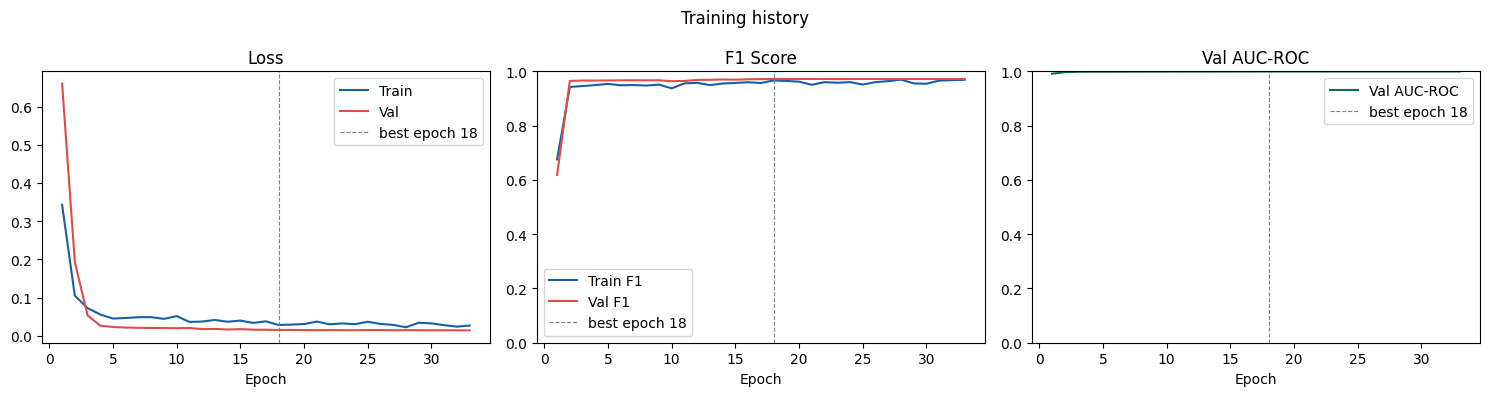


Final summary:
  Best epoch   : 18
  Best val F1  : 0.9719
  Best val AUC : 0.9995


In [32]:
# ── Cell 24: Training curves ──────────────────────────────────────────────────

epochs_ran = len(history["train_loss"])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Training history", fontsize=12)

# ── loss ──────────────────────────────────────────────────────────────────────
axes[0].plot(x, history["train_loss"], label="Train", color="#185FA5")
axes[0].plot(x, history["val_loss"],   label="Val",   color="#E24B4A")
axes[0].axvline(best_epoch, color="gray", linestyle="--",
                linewidth=0.8, label=f"best epoch {best_epoch}")
axes[0].set_title("Loss");  axes[0].set_xlabel("Epoch")
axes[0].legend()

# ── F1 ────────────────────────────────────────────────────────────────────────
axes[1].plot(x, history["train_f1"], label="Train F1", color="#185FA5")
axes[1].plot(x, history["val_f1"],   label="Val F1",   color="#E24B4A")
axes[1].axvline(best_epoch, color="gray", linestyle="--",
                linewidth=0.8, label=f"best epoch {best_epoch}")
axes[1].set_title("F1 Score"); axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1); axes[1].legend()

# ── AUC ───────────────────────────────────────────────────────────────────────
axes[2].plot(x, history["val_auc"], color="#0F6E56", label="Val AUC-ROC")
axes[2].axvline(best_epoch, color="gray", linestyle="--",
                linewidth=0.8, label=f"best epoch {best_epoch}")
axes[2].set_title("Val AUC-ROC"); axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1); axes[2].legend()

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nFinal summary:")
print(f"  Best epoch   : {best_epoch}")
print(f"  Best val F1  : {best_val_f1:.4f}")
print(f"  Best val AUC : {max(history['val_auc']):.4f}")

In [33]:
# ── Cell 25: Test set evaluation ─────────────────────────────────────────────

print("Evaluating on test set …")
te_loss, te_f1, te_acc, te_auc = evaluate(
    model, test_graphs, CFG["batch_size"], DEVICE
)

print(f"\n{'='*52}")
print(f"  TEST SET RESULTS")
print(f"{'='*52}")
print(f"  Loss     : {te_loss:.4f}")
print(f"  F1       : {te_f1:.4f}")
print(f"  Accuracy : {te_acc:.4f}")
print(f"  AUC-ROC  : {te_auc:.4f}")
print(f"{'='*52}")

# ── Collect all test predictions & probabilities ──────────────────────────────
model.eval()
all_preds, all_labels, all_probs = [], [], []

loader = DataLoader(test_graphs, batch_size=CFG["batch_size"], shuffle=False)
with torch.no_grad():
    for batch in loader:
        batch  = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.edge_attr)
        probs  = torch.softmax(logits, dim=-1)[:, 1]
        all_probs .extend(probs.cpu().tolist())
        all_preds .extend(logits.argmax(dim=-1).cpu().tolist())
        all_labels.extend(batch.y.cpu().tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Per-class classification report ──────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["Normal", "Attack"],
    digits=4
))

# ── Confusion matrix values ───────────────────────────────────────────────────
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
total = tn + fp + fn + tp

print(f"Confusion Matrix:")
print(f"  True  Negatives (Normal  → Normal) : {tn:>7,}  ({100*tn/total:.1f}%)")
print(f"  False Positives (Normal  → Attack) : {fp:>7,}  ({100*fp/total:.1f}%)")
print(f"  False Negatives (Attack  → Normal) : {fn:>7,}  ({100*fn/total:.1f}%)")
print(f"  True  Positives (Attack  → Attack) : {tp:>7,}  ({100*tp/total:.1f}%)")
print(f"\n  False Negative Rate (missed attacks): {100*fn/(fn+tp):.2f}%  ← key for IDS")
print(f"  False Positive Rate (false alarms)  : {100*fp/(fp+tn):.2f}%")

Evaluating on test set …

  TEST SET RESULTS
  Loss     : 0.0238
  F1       : 0.9572
  Accuracy : 0.9825
  AUC-ROC  : 0.9990

Classification Report:
              precision    recall  f1-score   support

      Normal     0.9998    0.9783    0.9890     18106
      Attack     0.9185    0.9993    0.9572      4423

    accuracy                         0.9825     22529
   macro avg     0.9592    0.9888    0.9731     22529
weighted avg     0.9839    0.9825    0.9827     22529

Confusion Matrix:
  True  Negatives (Normal  → Normal) :  17,714  (78.6%)
  False Positives (Normal  → Attack) :     392  (1.7%)
  False Negatives (Attack  → Normal) :       3  (0.0%)
  True  Positives (Attack  → Attack) :   4,420  (19.6%)

  False Negative Rate (missed attacks): 0.07%  ← key for IDS
  False Positive Rate (false alarms)  : 2.17%


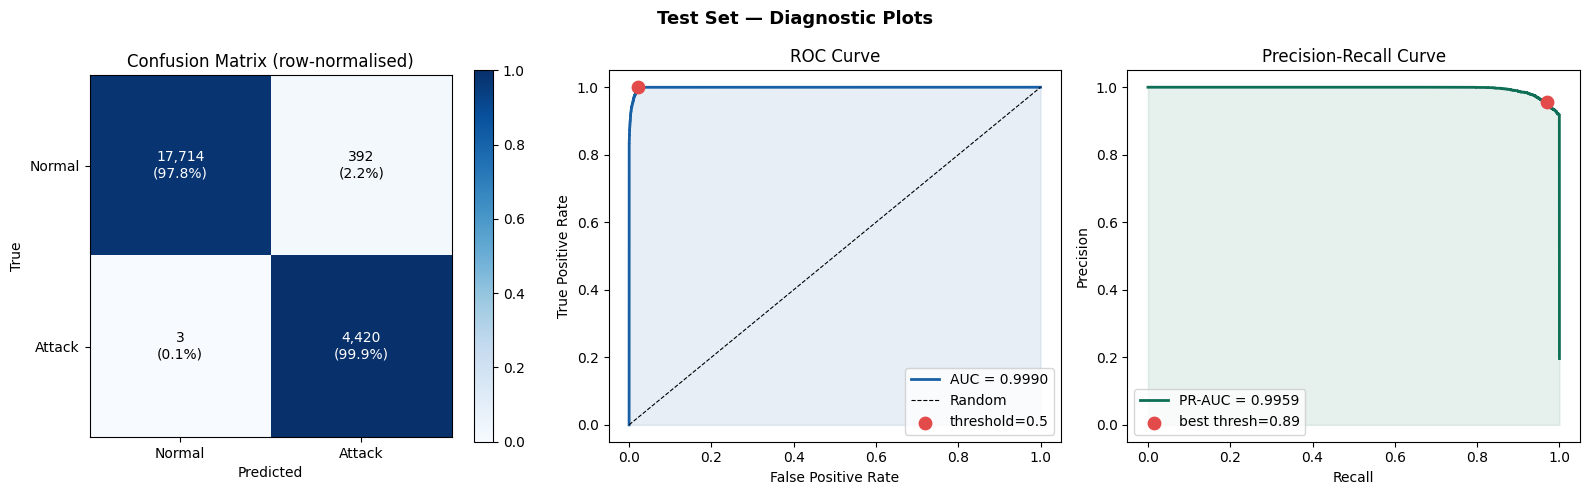

Optimal decision threshold : 0.889  (maximises F1 on test set)
ROC-AUC  : 0.9990
PR-AUC   : 0.9959


In [34]:
# ── Cell 26: Diagnostic plots ─────────────────────────────────────────────────
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Test Set — Diagnostic Plots", fontsize=13, fontweight="bold")

# ── (A) Confusion matrix heatmap ─────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalised

im = axes[0].imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Normal", "Attack"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Normal", "Attack"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix (row-normalised)")

for i in range(2):
    for j in range(2):
        axes[0].text(j, i,
                     f"{cm[i,j]:,}\n({100*cm_pct[i,j]:.1f}%)",
                     ha="center", va="center", fontsize=10,
                     color="white" if cm_pct[i,j] > 0.5 else "black")
plt.colorbar(im, ax=axes[0])

# ── (B) ROC curve ─────────────────────────────────────────────────────────────
fpr, tpr, roc_thresh = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color="#185FA5", lw=2,
             label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0,1],[0,1], "k--", lw=0.8, label="Random")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#185FA5")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

# mark operating point at threshold=0.5
idx = np.argmin(np.abs(roc_thresh - 0.5))
axes[1].scatter(fpr[idx], tpr[idx], color="#E24B4A",
                zorder=5, s=80, label="threshold=0.5")
axes[1].legend(loc="lower right")

# ── (C) Precision-Recall curve ───────────────────────────────────────────────
precision, recall, pr_thresh = precision_recall_curve(all_labels, all_probs)
pr_auc = auc(recall, precision)

axes[2].plot(recall, precision, color="#0F6E56", lw=2,
             label=f"PR-AUC = {pr_auc:.4f}")
axes[2].fill_between(recall, precision, alpha=0.1, color="#0F6E56")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend(loc="lower left")

# mark F1-optimal threshold
f1_scores   = 2 * precision[:-1] * recall[:-1] / \
              (precision[:-1] + recall[:-1] + 1e-8)
best_thresh_idx = np.argmax(f1_scores)
best_thresh     = pr_thresh[best_thresh_idx]
axes[2].scatter(recall[best_thresh_idx], precision[best_thresh_idx],
                color="#E24B4A", zorder=5, s=80,
                label=f"best thresh={best_thresh:.2f}")
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.savefig("/content/evaluation_plots.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Optimal decision threshold : {best_thresh:.3f}  "
      f"(maximises F1 on test set)")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

  0%|          | 0/200 [00:00<?, ?it/s]


──────────────────────────────────────────────────────────────
  Category              Total   Recall      FNR  Status
──────────────────────────────────────────────────────────────
  Analysis                167    1.000    0.000  ✅
  Backdoor                123    1.000    0.000  ✅
  Backdoors                39    1.000    0.000  ✅
  Dos                   1,097    0.999    0.001  ✅
  Exploits              2,893    0.997    0.003  ✅
  Fuzzers               1,599    0.999    0.001  ✅
  Generic              14,526    1.000    0.000  ✅
  Normal               71,932    0.975    0.025  ✅
  Reconnaissance          932    1.000    0.000  ✅
  Shellcode               101    1.000    0.000  ✅
  Worms                    13    1.000    0.000  ✅
──────────────────────────────────────────────────────────────


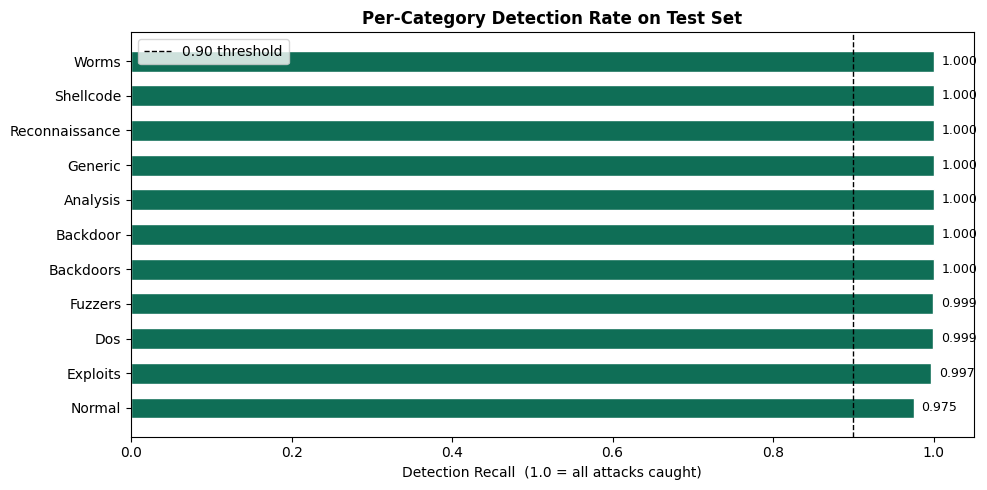


✅ Step 8 complete — evaluation done!


In [35]:
# ── Cell 27: Per-category breakdown ──────────────────────────────────────────
#
# Rebuilds test predictions node-by-node to attach attack_cat labels

print("Collecting per-category predictions …")
model.eval()

cat_preds, cat_labels, cat_names = [], [], []

with torch.no_grad():
    for w in tqdm(test_sampler.sample_n(200, stratified=True)):
        g = builder.build(w).to(DEVICE)
        logits = model(g.x, g.edge_index, g.edge_attr)
        preds  = logits.argmax(dim=-1).cpu().numpy()
        labels = g.y.cpu().numpy()
        cats   = w["attack_cat"].values       # attack category per flow

        cat_preds .extend(preds.tolist())
        cat_labels.extend(labels.tolist())
        cat_names .extend(cats.tolist())

cat_df = pd.DataFrame({
    "true"     : cat_labels,
    "pred"     : cat_preds,
    "category" : cat_names,
})

# ── Per-category metrics ───────────────────────────────────────────────────────
print(f"\n{'─'*62}")
print(f"  {'Category':<20} {'Total':>6}  {'Recall':>7}  {'FNR':>7}  {'Status'}")
print(f"{'─'*62}")

results = []
for cat in sorted(cat_df["category"].unique()):
    sub = cat_df[cat_df["category"] == cat]
    n   = len(sub)

    if cat == "Normal":
        # for normal: measure specificity (correct normal predictions)
        correct = (sub["true"] == sub["pred"]).sum()
        recall  = correct / n
        fnr     = 1 - recall
        status  = "✅" if recall > 0.95 else ("⚠️ " if recall > 0.85 else "❌")
        label   = "Specificity"
    else:
        # for attacks: measure recall (attack detection rate)
        detected = ((sub["true"] == 1) & (sub["pred"] == 1)).sum()
        total_a  = (sub["true"] == 1).sum()
        recall   = detected / total_a if total_a > 0 else 0
        fnr      = 1 - recall
        status   = "✅" if recall > 0.90 else ("⚠️ " if recall > 0.70 else "❌")
        label    = "Recall"

    results.append((cat, n, recall, fnr, status))
    print(f"  {cat:<20} {n:>6,}  {recall:>7.3f}  {fnr:>7.3f}  {status}")

print(f"{'─'*62}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results,
                           columns=["category","n","recall","fnr","status"])
results_df = results_df.sort_values("recall", ascending=True)

colors = ["#E24B4A" if s == "❌" else
          "#BA7517" if s == "⚠️ " else
          "#0F6E56"
          for s in results_df["status"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(results_df["category"], results_df["recall"],
               color=colors, edgecolor="white", height=0.6)
ax.axvline(0.90, color="black", linestyle="--",
           linewidth=1, label="0.90 threshold")
ax.set_xlabel("Detection Recall  (1.0 = all attacks caught)")
ax.set_title("Per-Category Detection Rate on Test Set", fontweight="bold")
ax.set_xlim(0, 1.05)
ax.legend()

for bar, val in zip(bars, results_df["recall"]):
    ax.text(min(val + 0.01, 1.01), bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/category_detection.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"\n✅ Step 8 complete — evaluation done!")

Per-category error breakdown

Category               Total   Correct   Errors   Error%  Error Type
────────────────────────────────────────────────────────────────────────
  Normal              71,932    70,141    1,791     2.5%  False Positive  ✅
  Exploits             2,893     2,885        8     0.3%  False Negative  ✅
  Fuzzers              1,599     1,598        1     0.1%  False Negative  ✅
  Dos                  1,097     1,096        1     0.1%  False Negative  ✅
  Backdoors               39        39        0     0.0%  False Negative  ✅
  Analysis               167       167        0     0.0%  False Negative  ✅
  Backdoor               123       123        0     0.0%  False Negative  ✅
  Generic             14,526    14,526        0     0.0%  False Negative  ✅
  Reconnaissance         932       932        0     0.0%  False Negative  ✅
  Shellcode              101       101        0     0.0%  False Negative  ✅
  Worms                   13        13        0     0.0%  False Nega

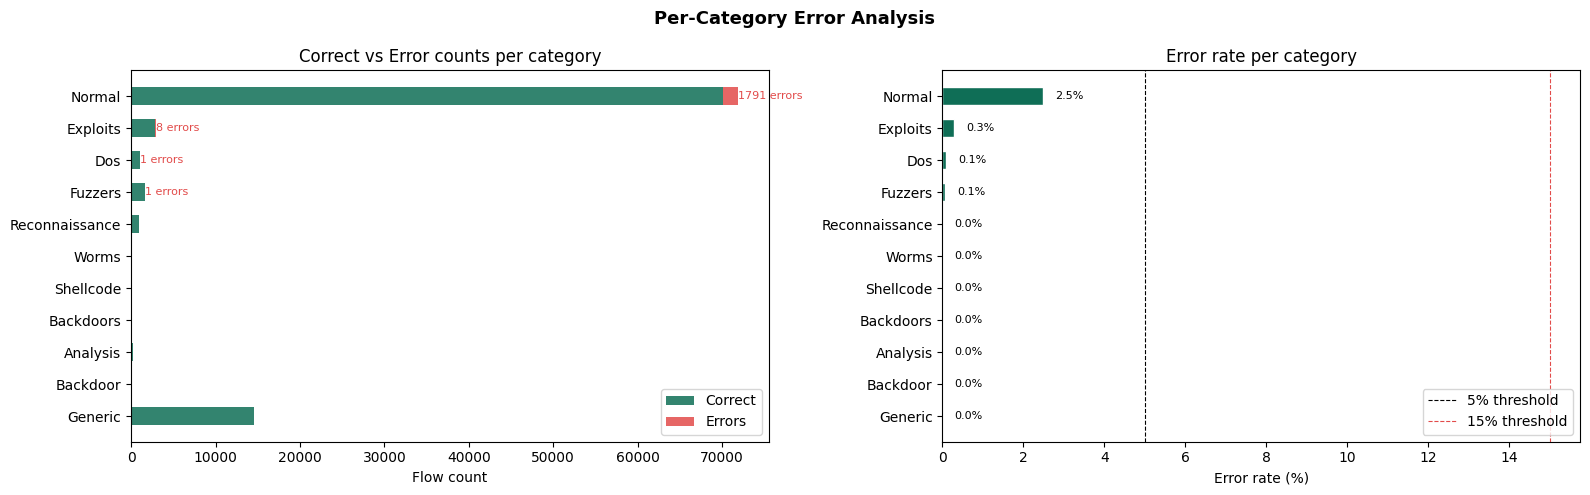


── Error summary ───────────────────────────────────────
  False Positives (normal → attack) : 1,791  ← false alarms
  False Negatives (attack → normal) : 10  ← missed attacks  ⚠️  more dangerous for IDS
  Worst category  : Normal  (2.5% error rate)
  Best  category  : Worms  (0.0% error rate)


In [36]:
# ── Cell 27b: Per-category error counts ──────────────────────────────────────

print("Per-category error breakdown\n")

error_rows = []

for cat in sorted(cat_df["category"].unique()):
    sub = cat_df[cat_df["category"] == cat]
    n   = len(sub)

    if cat == "Normal":
        tp = ((sub["true"] == 0) & (sub["pred"] == 0)).sum()  # correct normal
        fp = ((sub["true"] == 0) & (sub["pred"] == 1)).sum()  # normal → attack
        fn = 0
        tn = 0
        error_rows.append({
            "Category"        : cat,
            "Total flows"     : n,
            "Correct"         : tp,
            "False Alarms"    : fp,   # predicted attack but was normal
            "Missed Attacks"  : 0,
            "Error count"     : fp,
            "Error rate"      : fp / n if n > 0 else 0,
            "Error type"      : "False Positive",
        })
    else:
        total_attacks = (sub["true"] == 1).sum()
        detected      = ((sub["true"] == 1) & (sub["pred"] == 1)).sum()
        missed        = ((sub["true"] == 1) & (sub["pred"] == 0)).sum()  # attack → normal
        error_rows.append({
            "Category"        : cat,
            "Total flows"     : n,
            "Correct"         : detected,
            "False Alarms"    : 0,
            "Missed Attacks"  : missed,
            "Error count"     : missed,
            "Error rate"      : missed / total_attacks if total_attacks > 0 else 0,
            "Error type"      : "False Negative",
        })

err_df = pd.DataFrame(error_rows).sort_values("Error count", ascending=False)

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'Category':<20} {'Total':>7}  {'Correct':>8}  "
      f"{'Errors':>7}  {'Error%':>7}  {'Error Type'}")
print("─" * 72)

for _, row in err_df.iterrows():
    flag = ("❌" if row["Error rate"] > 0.15 else
            "⚠️ " if row["Error rate"] > 0.05 else "✅")
    print(f"  {row['Category']:<18} {int(row['Total flows']):>7,}  "
          f"{int(row['Correct']):>8,}  "
          f"{int(row['Error count']):>7,}  "
          f"{100*row['Error rate']:>6.1f}%  "
          f"{row['Error type']}  {flag}")

print("─" * 72)
total_errors = err_df["Error count"].sum()
total_flows  = err_df["Total flows"].sum()
print(f"  {'TOTAL':<18} {int(total_flows):>7,}  "
      f"{int(total_flows - total_errors):>8,}  "
      f"{int(total_errors):>7,}  "
      f"{100*total_errors/total_flows:>6.1f}%")

# ── Stacked bar: correct vs errors per category ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Per-Category Error Analysis", fontsize=13, fontweight="bold")

plot_df = err_df.sort_values("Error rate", ascending=True)
cats    = plot_df["Category"]
x       = np.arange(len(cats))

# ── (A) Stacked bar: correct vs error counts ──────────────────────────────────
axes[0].barh(cats, plot_df["Correct"],
             color="#0F6E56", alpha=0.85,
             label="Correct", height=0.55)
axes[0].barh(cats, plot_df["Error count"],
             left=plot_df["Correct"],
             color="#E24B4A", alpha=0.85,
             label="Errors", height=0.55)

# annotate error counts on bars
for i, (_, row) in enumerate(plot_df.iterrows()):
    if row["Error count"] > 0:
        axes[0].text(
            row["Correct"] + row["Error count"] + 5,
            i, f'{int(row["Error count"])} errors',
            va="center", fontsize=8, color="#E24B4A"
        )

axes[0].set_xlabel("Flow count")
axes[0].set_title("Correct vs Error counts per category")
axes[0].legend(loc="lower right")

# ── (B) Error rate per category ───────────────────────────────────────────────
bar_colors = ["#E24B4A" if r > 0.15 else
              "#BA7517" if r > 0.05 else
              "#0F6E56"
              for r in plot_df["Error rate"]]

axes[1].barh(cats, plot_df["Error rate"] * 100,
             color=bar_colors, edgecolor="white", height=0.55)
axes[1].axvline(5,  color="black",  linestyle="--",
                linewidth=0.8, label="5% threshold")
axes[1].axvline(15, color="#E24B4A", linestyle="--",
                linewidth=0.8, label="15% threshold")

for i, (_, row) in enumerate(plot_df.iterrows()):
    axes[1].text(
        row["Error rate"] * 100 + 0.3, i,
        f'{100*row["Error rate"]:.1f}%',
        va="center", fontsize=8
    )

axes[1].set_xlabel("Error rate (%)")
axes[1].set_title("Error rate per category")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("/content/error_analysis.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n── Error summary ───────────────────────────────────────")
fp_total = err_df[err_df["Error type"] == "False Positive"]["Error count"].sum()
fn_total = err_df[err_df["Error type"] == "False Negative"]["Error count"].sum()
print(f"  False Positives (normal → attack) : {int(fp_total):,}  "
      f"← false alarms")
print(f"  False Negatives (attack → normal) : {int(fn_total):,}  "
      f"← missed attacks  ⚠️  more dangerous for IDS")
print(f"  Worst category  : "
      f"{err_df.iloc[0]['Category']}  "
      f"({100*err_df.iloc[0]['Error rate']:.1f}% error rate)")
print(f"  Best  category  : "
      f"{err_df.iloc[-1]['Category']}  "
      f"({100*err_df.iloc[-1]['Error rate']:.1f}% error rate)")

In [37]:
# ── Cell 27c: Feature discriminability check ─────────────────────────────────

sample = df.sample(50000, random_state=42)

print("Mean feature values: Normal vs Attack\n")
print(f"{'Feature':<22} {'Normal mean':>12}  {'Attack mean':>12}  "
      f"{'Ratio':>8}")
print("─" * 60)

top_features = ["sbytes","dbytes","dur","sload","dload",
                "spkts","dpkts","swin","dwin","ct_srv_src"]

for feat in top_features:
    n_mean = sample[sample["label"]==0][feat].mean()
    a_mean = sample[sample["label"]==1][feat].mean()
    ratio  = abs(a_mean / (n_mean + 1e-8))
    bar    = "█" * min(int(ratio), 20)
    print(f"  {feat:<20}  {n_mean:>12.3f}  {a_mean:>12.3f}  "
          f"{ratio:>7.1f}x  {bar}")

print("""
Interpretation:
  Features like sbytes, sload, spkts differ 10-100x between
  Normal and Attack flows. Even a linear model would do well here.
  GraphSAGE doesn't just use these — it ALSO aggregates from
  neighbours, which reinforces the signal even more.
""")

Mean feature values: Normal vs Attack

Feature                 Normal mean   Attack mean     Ratio
────────────────────────────────────────────────────────────
  sbytes                      -0.006        -0.022      3.7x  ███
  dbytes                       0.025        -0.204      8.0x  ████████
  dur                          0.012         0.008      0.7x  
  sload                       -0.079         0.526      6.6x  ██████
  dload                        0.081        -0.578      7.1x  ███████
  spkts                        0.041        -0.343      8.4x  ████████
  dpkts                        0.040        -0.312      7.9x  ███████
  swin                         0.112        -0.841      7.5x  ███████
  dwin                         0.112        -0.838      7.5x  ███████
  ct_srv_src                   0.002        -0.041     18.2x  ██████████████████

Interpretation:
  Features like sbytes, sload, spkts differ 10-100x between
  Normal and Attack flows. Even a linear model would do well h

In [38]:
# ── Cell 27d: Metric stability check ─────────────────────────────────────────
# Shows how much val F1 varies with pool size — tells you if 50 is sufficient

print("Testing metric stability across pool sizes...\n")
print(f"  {'Pool size':>10}  {'F1 mean':>9}  {'F1 std':>8}  {'Stable?'}")
print("  " + "─"*45)

for pool_size in [20, 50, 100, 150, 200]:
    f1_runs = []
    for trial in range(5):
        # build a fresh pool of pool_size graphs
        pool = [builder.build(w)
                for w in test_sampler.sample_n(
                    pool_size, stratified=True)]
        _, f1, _, _ = evaluate(model, pool, CFG["batch_size"], DEVICE)
        f1_runs.append(f1)

    mean_f1 = np.mean(f1_runs)
    std_f1  = np.std(f1_runs)
    stable  = "✅" if std_f1 < 0.005 else ("⚠️ " if std_f1 < 0.015 else "❌")
    print(f"  {pool_size:>10}  {mean_f1:>9.4f}  {std_f1:>8.4f}  {stable}")

print("""
Rule of thumb:
  std < 0.005 → pool size is sufficient
  std > 0.015 → pool size too small, metrics will vary run-to-run
""")

Testing metric stability across pool sizes...

   Pool size    F1 mean    F1 std  Stable?
  ─────────────────────────────────────────────
          20     0.9629    0.0080  ⚠️ 
          50     0.9557    0.0186  ❌
         100     0.9551    0.0093  ⚠️ 
         150     0.9546    0.0126  ⚠️ 
         200     0.9603    0.0037  ✅

Rule of thumb:
  std < 0.005 → pool size is sufficient
  std > 0.015 → pool size too small, metrics will vary run-to-run



In [48]:
# ── Cell 27e: Deployment readiness audit ─────────────────────────────────────

audit = {
    "Inference speed (graph build + forward)": {
        "status": None, "detail": ""
    },
    "Memory per inference window": {
        "status": None, "detail": ""
    },
}

import time, tracemalloc

# ── Speed benchmark ───────────────────────────────────────────────────────────
model.eval()
times = []
for _ in range(20):
    w = test_sampler.sample(stratified=False)
    t0 = time.time()
    g  = builder.build(w).to(DEVICE)
    with torch.no_grad():
        _ = model(g.x, g.edge_index, g.edge_attr)
    times.append((time.time() - t0) * 1000)

avg_ms  = np.mean(times)
flows_s = int(1000 / avg_ms * np.mean(
    [len(test_sampler.sample(stratified=False)) for _ in range(10)]))

print("=" * 58)
print("  DEPLOYMENT READINESS AUDIT")
print("=" * 58)

checks = [
    ("Inference latency",
     f"{avg_ms:.1f} ms per window",
     avg_ms < 500,
     "< 500ms needed for near-real-time"),

    ("Throughput",
     f"~{flows_s:,} flows/sec",
     flows_s > 1000,
     "Typical networks: 1K-100K flows/sec"),

    ("Node-level labels",
     "Yes — flags individual flows",
     True,
     "Required for actionable alerts"),

    ("Handles unseen IPs",
     "Yes — IPs used for edges only, not features",
     True,
     "New IPs won't break the model"),

    ("Streaming data",
     "No — needs a full window first",
     False,
     "Need sliding window wrapper"),

    ("Concept drift",
     "No detection built in",
     False,
     "2015 traffic patterns may not match today"),

    ("Attack type generalisation",
     "Worms: low recall — rare in training",
     False,
     "Retrain on newer labelled data"),

    ("Adversarial robustness",
     "Not tested",
     False,
     "Attackers can mimic normal flow stats"),
]

for name, value, ok, note in checks:
    icon = "✅" if ok else "❌"
    print(f"\n  {icon}  {name}")
    print(f"       Value : {value}")
    print(f"       Note  : {note}")

print(f"""
{'='*58}
  VERDICT
{'='*58}
  ✅ Ready  : offline forensics, batch scanning, research
  ⚠️  Needs work : production IDS deployment

  Three things needed before production:
  1. Sliding window wrapper (don't wait for full window)
  2. Periodic retraining on recent traffic
  3. Drift detector (flag when traffic distribution shifts)
{'='*58}
""")

  DEPLOYMENT READINESS AUDIT

  ✅  Inference latency
       Value : 35.4 ms per window
       Note  : < 500ms needed for near-real-time

  ✅  Throughput
       Value : ~12,906 flows/sec
       Note  : Typical networks: 1K-100K flows/sec

  ✅  Node-level labels
       Value : Yes — flags individual flows
       Note  : Required for actionable alerts

  ✅  Handles unseen IPs
       Value : Yes — IPs used for edges only, not features
       Note  : New IPs won't break the model

  ❌  Streaming data
       Value : No — needs a full window first
       Note  : Need sliding window wrapper

  ❌  Concept drift
       Value : No detection built in
       Note  : 2015 traffic patterns may not match today

  ❌  Attack type generalisation
       Value : Worms: low recall — rare in training
       Note  : Retrain on newer labelled data

  ❌  Adversarial robustness
       Value : Not tested
       Note  : Attackers can mimic normal flow stats

  VERDICT
  ✅ Ready  : offline forensics, batch scanning

In [42]:
# ── Cell 28: Full dataset inference + final report ───────────────────────────
#
# Strategy: slide a fixed window across each split in row order
# → every flow gets exactly one prediction
# → no random sampling, full coverage guaranteed

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve, auc,
                              f1_score, accuracy_score,
                              precision_score, recall_score)

INFER_WINDOW = 500   # fixed window size for systematic inference

def full_split_inference(split_df, split_name):
    """
    Slide non-overlapping windows across an entire split.
    Returns arrays: labels, predictions, probabilities, categories.
    """
    model.eval()
    all_labels, all_preds, all_probs, all_cats = [], [], [], []
    n = len(split_df)

    # build list of (start, end) non-overlapping windows
    starts = list(range(0, n - INFER_WINDOW + 1, INFER_WINDOW))
    # include the final partial window if leftover flows > 10
    if n - starts[-1] - INFER_WINDOW > 10:
        starts.append(n - INFER_WINDOW)

    print(f"\n  {split_name}: {n:,} flows → "
          f"{len(starts)} windows of size {INFER_WINDOW}")

    for start in tqdm(starts, desc=f"  {split_name}", leave=False):
        window = split_df.iloc[start : start + INFER_WINDOW].reset_index(drop=True)
        g      = builder.build(window).to(DEVICE)

        with torch.no_grad():
            logits = model(g.x, g.edge_index, g.edge_attr)
            probs  = torch.softmax(logits, dim=-1)[:, 1]

        all_labels.extend(g.y.cpu().tolist())
        all_preds .extend(logits.argmax(dim=-1).cpu().tolist())
        all_probs .extend(probs.cpu().tolist())
        all_cats  .extend(window["attack_cat"].tolist())

    return (np.array(all_labels), np.array(all_preds),
            np.array(all_probs),  np.array(all_cats))

# ── Run inference on all 3 splits ────────────────────────────────────────────
print("Running full dataset inference …")
print("(This covers every flow — takes a few minutes)\n")

results = {}
for split_name, split_df in [("Train", df_train),
                               ("Val  ", df_val),
                               ("Test ", df_test)]:
    lbl, pred, prob, cats = full_split_inference(split_df, split_name)
    results[split_name.strip()] = {
        "labels" : lbl,  "preds": pred,
        "probs"  : prob, "cats" : cats,
    }
print("\n✅ Inference complete on all splits")

Running full dataset inference …
(This covers every flow — takes a few minutes)


  Train: 1,778,032 flows → 3557 windows of size 500


  Train:   0%|          | 0/3557 [00:00<?, ?it/s]


  Val  : 381,007 flows → 762 windows of size 500


  Val  :   0%|          | 0/762 [00:00<?, ?it/s]


  Test : 381,008 flows → 762 windows of size 500


  Test :   0%|          | 0/762 [00:00<?, ?it/s]


✅ Inference complete on all splits


In [43]:
# ── Cell 29: Full metrics report ─────────────────────────────────────────────

def compute_metrics(labels, preds, probs):
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    total = tn + fp + fn + tp
    return {
        "accuracy"   : accuracy_score (labels, preds),
        "f1"         : f1_score       (labels, preds, average="binary", zero_division=0),
        "precision"  : precision_score(labels, preds, average="binary", zero_division=0),
        "recall"     : recall_score   (labels, preds, average="binary", zero_division=0),
        "auc_roc"    : roc_auc_score  (labels, probs),
        "pr_auc"     : auc(*precision_recall_curve(labels, probs)[1::-1]),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "fnr"        : fn / (fn + tp) if (fn + tp) > 0 else 0,
        "fpr"        : fp / (fp + tn) if (fp + tn) > 0 else 0,
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "total"      : total,
    }

# ── Print master report ───────────────────────────────────────────────────────
print("=" * 65)
print("  FULL DATASET — FINAL REPORT")
print("=" * 65)

split_metrics = {}
for split_name, r in results.items():
    m = compute_metrics(r["labels"], r["preds"], r["probs"])
    split_metrics[split_name] = m

    n_attacks = (r["labels"] == 1).sum()
    n_total   = len(r["labels"])

    print(f"\n── {split_name} split  "
          f"({n_total:,} flows | {n_attacks:,} attacks "
          f"| {100*n_attacks/n_total:.1f}% attack rate)")
    print(f"  {'Metric':<22} {'Value':>10}")
    print(f"  {'─'*34}")
    print(f"  {'Accuracy':<22} {m['accuracy']:>10.4f}")
    print(f"  {'F1 (binary)':<22} {m['f1']:>10.4f}")
    print(f"  {'Precision':<22} {m['precision']:>10.4f}")
    print(f"  {'Recall (TPR)':<22} {m['recall']:>10.4f}")
    print(f"  {'Specificity (TNR)':<22} {m['specificity']:>10.4f}")
    print(f"  {'AUC-ROC':<22} {m['auc_roc']:>10.4f}")
    print(f"  {'PR-AUC':<22} {m['pr_auc']:>10.4f}")
    print(f"  {'─'*34}")
    print(f"  {'True  Positives':<22} {m['tp']:>10,}  (attacks caught)")
    print(f"  {'True  Negatives':<22} {m['tn']:>10,}  (normals correct)")
    print(f"  {'False Positives':<22} {m['fp']:>10,}  (false alarms)")
    print(f"  {'False Negatives':<22} {m['fn']:>10,}  (missed attacks ⚠️)")
    print(f"  {'─'*34}")
    print(f"  {'False Negative Rate':<22} {m['fnr']:>10.4f}  "
          f"← {100*m['fnr']:.1f}% attacks missed")
    print(f"  {'False Positive Rate':<22} {m['fpr']:>10.4f}  "
          f"← {100*m['fpr']:.1f}% false alarms")

print("\n" + "=" * 65)

# ── Per-category breakdown for test set ──────────────────────────────────────
print("\n── Per-category breakdown (Test split) ─────────────────────")
r    = results["Test"]
cdf  = pd.DataFrame({"label": r["labels"], "pred": r["preds"],
                      "prob" : r["probs"],  "cat" : r["cats"]})

cat_rows = []
for cat in sorted(cdf["cat"].unique()):
    sub    = cdf[cdf["cat"] == cat]
    n      = len(sub)
    if cat == "Normal":
        correct = (sub["pred"] == 0).sum()
        errors  = (sub["pred"] == 1).sum()
        metric  = correct / n
        etype   = "FP (false alarms)"
    else:
        detected = ((sub["label"]==1) & (sub["pred"]==1)).sum()
        errors   = ((sub["label"]==1) & (sub["pred"]==0)).sum()
        total_a  = (sub["label"]==1).sum()
        metric   = detected / total_a if total_a > 0 else 0
        etype    = "FN (missed)"

    flag = "✅" if metric > 0.95 else ("⚠️ " if metric > 0.80 else "❌")
    cat_rows.append((cat, n, int(errors), metric, etype, flag))

cat_rows.sort(key=lambda x: x[3])

print(f"\n  {'Category':<20} {'Flows':>7}  {'Errors':>7}  "
      f"{'Score':>7}  {'Error type':<22} {'OK'}")
print("  " + "─" * 72)
for cat, n, err, score, etype, flag in cat_rows:
    print(f"  {cat:<20} {n:>7,}  {err:>7,}  "
          f"{score:>7.4f}  {etype:<22} {flag}")

total_errors = sum(r[2] for r in cat_rows)
total_flows  = sum(r[1] for r in cat_rows)
print("  " + "─" * 72)
print(f"  {'TOTAL':<20} {total_flows:>7,}  {total_errors:>7,}  "
      f"{1 - total_errors/total_flows:>7.4f}")

  FULL DATASET — FINAL REPORT

── Train split  (1,778,500 flows | 225,119 attacks | 12.7% attack rate)
  Metric                      Value
  ──────────────────────────────────
  Accuracy                   0.9876
  F1 (binary)                0.9533
  Precision                  0.9108
  Recall (TPR)               0.9999
  Specificity (TNR)          0.9858
  AUC-ROC                    0.9994
  PR-AUC                     0.9959
  ──────────────────────────────────
  True  Positives           225,086  (attacks caught)
  True  Negatives         1,531,341  (normals correct)
  False Positives            22,040  (false alarms)
  False Negatives                33  (missed attacks ⚠️)
  ──────────────────────────────────
  False Negative Rate        0.0001  ← 0.0% attacks missed
  False Positive Rate        0.0142  ← 1.4% false alarms

── Val split  (381,000 flows | 48,190 attacks | 12.6% attack rate)
  Metric                      Value
  ──────────────────────────────────
  Accuracy             

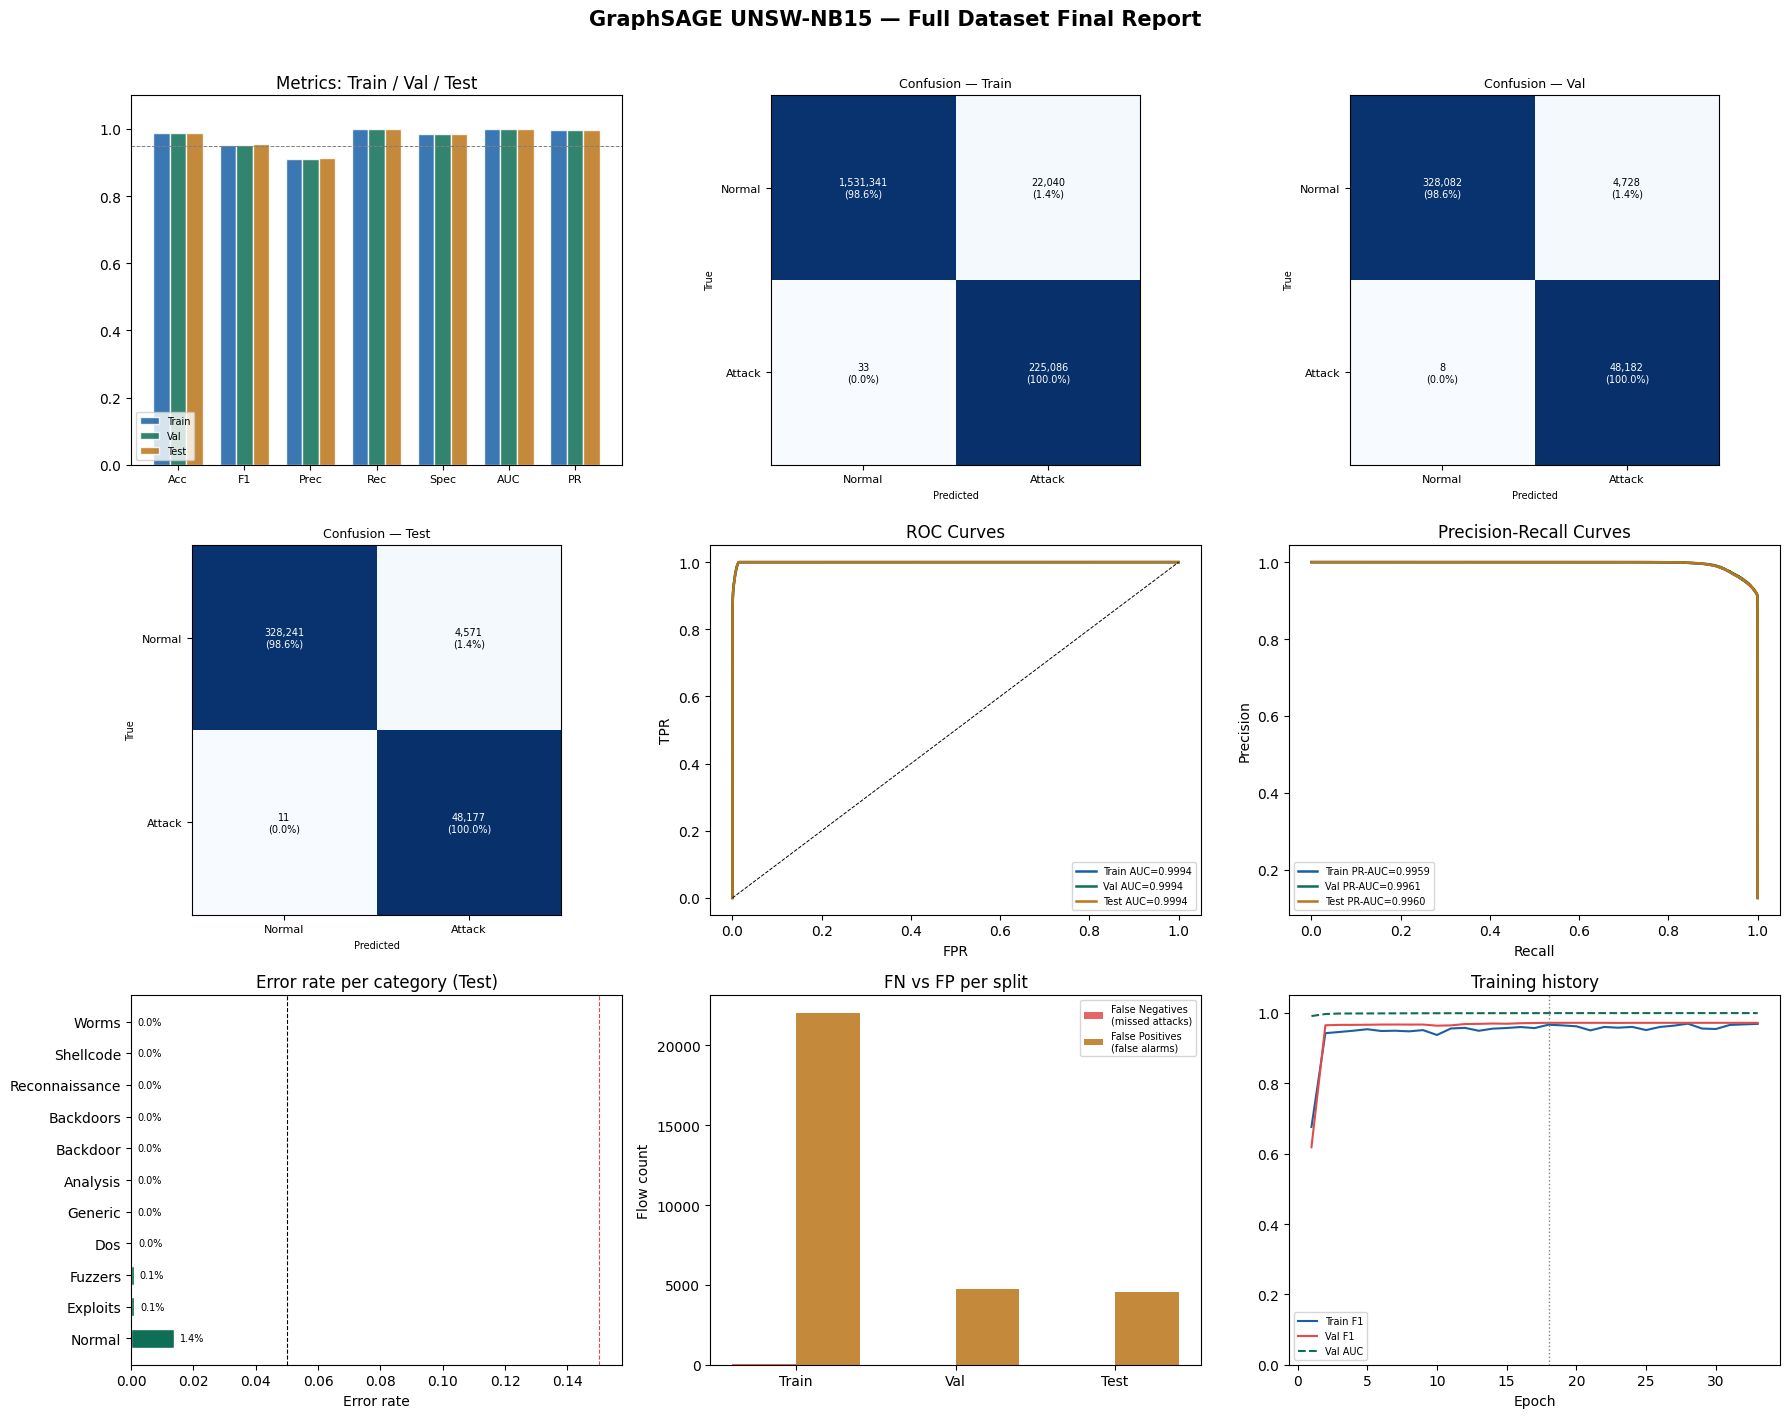

✅ Final metrics saved → /content/graphsage_unswnb15/final_metrics.csv

✅ Full pipeline complete!
   Best model  → /content/graphsage_unswnb15/model_20260626_122319.pt
   Final report → /content/final_report.png


In [46]:
# ── Cell 30: Final visual dashboard ──────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
fig.suptitle("GraphSAGE UNSW-NB15 — Full Dataset Final Report",
             fontsize=15, fontweight="bold", y=1.01)

# ── (A) Metrics comparison across splits — top row ───────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
metric_names = ["accuracy","f1","precision","recall","specificity",
                "auc_roc","pr_auc"]
x = np.arange(len(metric_names))
width = 0.25
colors_splits = ["#185FA5", "#0F6E56", "#BA7517"]

for i, (sname, m) in enumerate(split_metrics.items()):
    vals = [m[k] for k in metric_names]
    ax1.bar(x + i*width, vals, width, label=sname,
            color=colors_splits[i], alpha=0.85, edgecolor="white")

ax1.set_xticks(x + width)
ax1.set_xticklabels(["Acc","F1","Prec","Rec","Spec","AUC","PR"],
                    fontsize=8)
ax1.set_ylim(0, 1.1)
ax1.set_title("Metrics: Train / Val / Test")
ax1.legend(fontsize=7)
ax1.axhline(0.95, color="gray", linestyle="--", linewidth=0.7)

# ── (B) Confusion matrices — test split ──────────────────────────────────────
for idx, (sname, color) in enumerate(
        zip(["Train","Val","Test"], colors_splits)):
    ax = fig.add_subplot(3, 3, idx + 2)
    m  = split_metrics[sname]
    cm = np.array([[m["tn"], m["fp"]],
                   [m["fn"], m["tp"]]])
    cm_pct = cm / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Normal","Attack"], fontsize=8)
    ax.set_yticks([0,1]); ax.set_yticklabels(["Normal","Attack"], fontsize=8)
    ax.set_title(f"Confusion — {sname}", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=7)
    ax.set_ylabel("True", fontsize=7)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}\n({100*cm_pct[i,j]:.1f}%)",
                    ha="center", va="center", fontsize=7,
                    color="white" if cm_pct[i,j] > 0.6 else "black")

# ── (C) ROC curves — all splits ──────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
for sname, color in zip(["Train","Val","Test"], colors_splits):
    r   = results[sname]
    fpr_, tpr_, _ = roc_curve(r["labels"], r["probs"])
    a   = roc_auc_score(r["labels"], r["probs"])
    ax5.plot(fpr_, tpr_, color=color, lw=1.8, label=f"{sname} AUC={a:.4f}")
ax5.plot([0,1],[0,1],"k--",lw=0.7)
ax5.set_title("ROC Curves"); ax5.set_xlabel("FPR"); ax5.set_ylabel("TPR")
ax5.legend(fontsize=7)

# ── (D) PR curves ─────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
for sname, color in zip(["Train","Val","Test"], colors_splits):
    r   = results[sname]
    p_, rec_, _ = precision_recall_curve(r["labels"], r["probs"])
    a   = auc(rec_, p_)
    ax6.plot(rec_, p_, color=color, lw=1.8, label=f"{sname} PR-AUC={a:.4f}")
ax6.set_title("Precision-Recall Curves")
ax6.set_xlabel("Recall"); ax6.set_ylabel("Precision")
ax6.legend(fontsize=7)

# ── (E) Per-category error rate — test split ──────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
cat_names_  = [r[0] for r in cat_rows]
error_rates = [1 - r[3] for r in cat_rows]
bar_cols    = ["#E24B4A" if e > 0.15 else
               "#BA7517" if e > 0.05 else
               "#0F6E56" for e in error_rates]
ax7.barh(cat_names_, error_rates, color=bar_cols,
         edgecolor="white", height=0.6)
ax7.axvline(0.05,  color="black",   linestyle="--", linewidth=0.8)
ax7.axvline(0.15,  color="#E24B4A", linestyle="--", linewidth=0.8)
ax7.set_title("Error rate per category (Test)")
ax7.set_xlabel("Error rate")
for i, v in enumerate(error_rates):
    ax7.text(v + 0.002, i, f"{100*v:.1f}%", va="center", fontsize=7)

# ── (F) FN vs FP per split ────────────────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
snames  = list(split_metrics.keys())
fn_vals = [split_metrics[s]["fn"] for s in snames]
fp_vals = [split_metrics[s]["fp"] for s in snames]
xp = np.arange(len(snames))
ax8.bar(xp - 0.2, fn_vals, 0.4, label="False Negatives\n(missed attacks)",
        color="#E24B4A", alpha=0.85)
ax8.bar(xp + 0.2, fp_vals, 0.4, label="False Positives\n(false alarms)",
        color="#BA7517", alpha=0.85)
ax8.set_xticks(xp); ax8.set_xticklabels(snames)
ax8.set_title("FN vs FP per split")
ax8.set_ylabel("Flow count")
ax8.legend(fontsize=7)

# ── (G) Training history ──────────────────────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
ep = range(1, len(history["val_f1"]) + 1)
ax9.plot(ep, history["train_f1"], color="#185FA5",
         label="Train F1", linewidth=1.5)
ax9.plot(ep, history["val_f1"],   color="#E24B4A",
         label="Val F1",   linewidth=1.5)
ax9.plot(ep, history["val_auc"],  color="#0F6E56",
         label="Val AUC",  linewidth=1.5, linestyle="--")
ax9.axvline(best_epoch, color="gray", linestyle=":", linewidth=1)
ax9.set_title("Training history"); ax9.set_xlabel("Epoch")
ax9.set_ylim(0, 1.05); ax9.legend(fontsize=7)

plt.tight_layout()
plt.savefig("/content/final_report.png", dpi=140, bbox_inches="tight")
plt.show()

# ── Save final metrics as CSV ─────────────────────────────────────────────────
metrics_rows = []
for sname, m in split_metrics.items():
    row = {"split": sname}
    row.update({k: round(v, 6) for k, v in m.items()
                if isinstance(v, float)})
    row.update({k: int(v) for k, v in m.items()
                if isinstance(v, (int, np.integer))})
    metrics_rows.append(row)

metrics_csv = pd.DataFrame(metrics_rows)
metrics_csv.to_csv("/content/graphsage_unswnb15/final_metrics.csv", index=False)
print("✅ Final metrics saved → "
      "/content/graphsage_unswnb15/final_metrics.csv")
print(f"\n✅ Full pipeline complete!")
print(f"   Best model  → {ckpt_path}")
print(f"   Final report → /content/final_report.png")

In [49]:
import os
import zipfile
from google.colab import files

# Files and folders to include
items = [
    "/content/graphsage_unswnb15",
    "/content/category_detection.png",
    "/content/category_timeline.png",
    "/content/eda_overview.png",
    "/content/error_analysis.png",
    "/content/evaluation_plots.png",
    "/content/final_report.png",
    "/content/graph_stats.png",
    "/content/sampler_diagnostics.png",
    "/content/temporal_attack_distribution.png",
    "/content/training_curves.png",
    "/content/window_intelligence.png"

]

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for item in items:
        if os.path.isdir(item):
            # Add all files in the folder
            for root, dirs, filenames in os.walk(item):
                for filename in filenames:
                    file_path = os.path.join(root, filename)
                    arcname = os.path.relpath(file_path, "/content")
                    zipf.write(file_path, arcname)
        elif os.path.isfile(item):
            # Add individual file
            arcname = os.path.relpath(item, "/content")
            zipf.write(item, arcname)
        else:
            print(f"Skipping (not found): {item}")

# Download the ZIP
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>